In [ ]:
! which python

'which' is not recognized as an internal or external command,
operable program or batch file.


# Homework 4
   
 - All questions must be answered in your own words, do not copy-paste text from the internet. Points can be deducted for terrible formatting or incomprehensible English.

 - Code must be commented. If you use code you found online, you have to add the link to the source you used. There is no penalty for using outside sources as long as you convince us you understand the code.

  **To pass the homework you need to attempt to do all tasks. If we see that you misunderstand some concept, you may receive personal feedback and you can have a chance to resubmit your homework.**
 **Please treat these homeworks as learning opportunities to support your study! Instead of copy-pasting solution, attempt to do it yourself and rather learn from feedback**

**You can earn up to 5 bonus points by tuning the hyperparameters and reaching test accuracies above 52%**

*Once completed zip the entire directory containing this exercise and upload it to Moodle.
   
For background reading see http://cs231n.github.io/optimization-2/  
http://vision.stanford.edu/teaching/cs231n/handouts/derivatives.pdf  
https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf



## Applied Theory

In this exercise we have a neural network with one hidden layer. This time we derive gradients slightly differently:
1. we use batch of samples instead of one sample,
2. **we use matrix calculus for gradients,**
3. we add L2 regularization to the loss.

![alt text][logo]

[logo]: http://cs231n.github.io/assets/nn1/neural_net.jpeg "Logo Title Text 2"


Notation:
 * $\mathbf{X}$ is $N \times D$ input matrix, where $N$ is number of samples in batch and $D$ is number of features.
 * $\mathbf{Y}$ is $N \times C$ one-hot coded target matrix, where $N$ is number of samples in batch and $C$ is number of classes.
 * $\mathbf{c}$ is $N$-dimensional vector of correct classes for all samples, $\mathbf{c}_i \in \{1, \ldots, C\}$.
 * $\mathbf{W}^{(1)}$ is $D \times M$ weight matrix of the first layer, where $D$ is the number of features and $M$ is number of hidden nodes.
 * $\mathbf{W}^{(2)}$ is $M \times C$ weight matrix of the second layer, where $M$ is the number of hidden nodes and $C$ is the number of classes.
 * $\mathbf{b}^{(1)}$ is bias vector of the first layer with dimension of $1 \times M$.
 * $\mathbf{b}^{(2)}$ is bias vector of the second layer with dimension of $1 \times C$.
 * $1_N$ is a column vector of ones of length N with dimension $N \times 1$
 * $\text{ReLU}(x) = \max(x, 0)$ is rectified linear unit activation function.
 * $\mathbf{P} = \text{softmax}(\mathbf{A})$ converts activations into probabilities row by row $\mathbf{P}_{ij} = \frac{e^ {\mathbf{A}_{ij}}}{\sum_k e^{\mathbf{A}_{ik}}}$.



**Feed-forward pass:**
$$
\begin{align*}
\mathbf{A}^{(1)} &= \mathbf{X} \mathbf{W}^{(1)} + 1_N \mathbf{b}^{(1)}   &(N\times M)
\\
\mathbf{H}^{(1)} &= \text{ReLU}(\mathbf{A}^{(1)}) &(N\times M)
\\
\mathbf{A}^{(2)} &= \mathbf{H}^{(1)} \mathbf{W}^{(2)} + 1_N \mathbf{b}^{(2)} &(N\times C)
\\
\mathbf{P} &= \text{softmax}(\mathbf{A}^{(2)}) &(N\times C)
\\
L_{CE} &= -\frac{1}{N} \sum_{i=1}^{N} \mathbf{Y}_{i\cdot} \odot \log \mathbf{P}_{i\cdot} = 
-\frac{1}{N} \sum_{i=1}^{N} \log \mathbf{P}_{i\mathbf{c}_i}   &(\text{scalar})
\end{align*}
$$

Here $AB$ is matrix multiplication and $A\odot B$ is element-wise multiplication.  
$\frac{1}{N}$ in the loss function produces mean instance loss, which is good because then loss value does not depend on batch size. If we had used sum, both loss value and gradients would have different magnitude for different batch sizes and we would need to adapt learning rate for each batch size.

<br><br>
**Backward pass:**  
Derivatives of matrix multiplication work very similarly to the scalar case. However, as the order of elements in product matters (AB $\neq$ BA), pay attention to transposes and also on which side of the overall expression the derviative ends up. Suppose  
  $$ L = f(Y),\qquad Y = XW.$$
Then
\begin{align*}
\frac{\partial L}{\partial X} &=  \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial X}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial X} =\frac{\partial L}{\partial Y} W^T\\
\frac{\partial L}{\partial W} &= \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial W}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial W} = X^T  \frac{\partial L}{\partial Y}.
\end{align*}
Notice that the multiplication with transposed matrix is from different sides in these two cases.

Backward pass for $\mathbf{W}^{(1)}$ using chain rule:
\begin{align*}
    \frac{\partial L_{CE}}{\partial\mathbf{W}^{(1)}} &= \frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}}\frac{\partial \mathbf{A}^{(1)}}{\partial\mathbf{W}^{(1)}} & \text{(chain rule)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}} & \text{(previous formula)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\frac{\partial\mathbf{H}^{(1)}}{\partial\mathbf{A}^{(1)}} & \text{(chain rule)}\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}\frac{\partial\mathbf{A}^{(2)}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)&\text{(chain rule)}\\
    &= X^T\left(\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(previous formula)}\\
    &= \frac{1}{N}X^T\left(\left((P-Y)(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(from previous practice)}
\end{align*}
Here $(\mathbf{A}^{(1)}>0)$ denotes a matrix whose value at row $i$ and column $j$ is one, if the corresponding value in matrix $\mathbf{A}$ is greater than 0, and 0 otherwise.

Write down the partial derivatives of classification loss function with respect to other weights and biases.

The partial derivatives of classification loss function with respect to other weights and biases adjust the parameters of the artificial neural network.

The resulting shape of the matrices shows the compatibility with the network architecture.

#### **!NB** These partial derivatives will help you to do the tasks below. Verify that the dimensions match!

\begin{align*}
\frac{\partial L_{CE}}{\partial\mathbf{W}^{(2)}} &= . . .
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(1)}} &= . . . 
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(2)}} &= . . .
\end{align*}


## L2 regularization

L2 regularization drives the weights to be small.
$$
L_r = \sum_{ij} (\mathbf{W}^{(1)}_{ij})^2 + \sum_{ij} (\mathbf{W}^{(2)}_{ij})^2
$$

In the final loss the classification loss and regularization loss are added together.
$$
L = L_c + \lambda L_r
$$

The strenght of regularization is determined by regularization coefficient $\lambda$.

The derivatives of the regularization penalty for both layers.

#### **!NB** These partial derivates will help you to do the tasks below. Verify that the dimensions match!

$$
\begin{align*}
\frac{\partial L_r}{\partial\mathbf{W}^{(1)}} &= . . .
\\
\frac{\partial L_r}{\partial\mathbf{W}^{(2)}} &= . . .
\end{align*}
$$

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):

    """ returns relative error """

    x = x.to(torch.float64)
    y = y.to(torch.float64)
    return torch.max(torch.abs(x - y) / (torch.max(torch.tensor(1e-8, dtype=torch.float64), torch.abs(x) + torch.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use the class `TwoLayerNet` in the file `neural_net.py` to represent instances of our network. The network parameters are stored in the instance variable `self.params` where keys are string parameter names and values are torch tensors. Below, we initialize toy data and a toy model that we will use to develop your implementation.

In [ ]:
# Create a small net and some toy data to check your implementations.
# Note that we set the random seed for repeatable experiments.

def init_toy_model(input_size, hidden_size, num_classes, std):
    """
    Initialize the model. 
    Weights are initialized to small random values and biases are initialized to zero.
    """
    net = TwoLayerNet(input_size, hidden_size, num_classes, std)
    return net

def init_toy_data(num_samples, input_size):

    X = 10 * torch.randn(num_samples, input_size, dtype=torch.float64)
    y = torch.tensor([0, 1, 2, 2, 1], dtype=torch.long)
    
    return X, y


input_size = 4
hidden_size = 10
num_classes = 3
num_samples = 5
std = 1e-1

torch.manual_seed(0)
net = init_toy_model(input_size, hidden_size, num_classes, std)
X, y = init_toy_data(num_samples, input_size)

print('')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


X shape: torch.Size([5, 4])
y shape: torch.Size([5])


# Forward pass: compute scores

### Task 4.1
Open the file `neural_net.py` and look at the method `TwoLayerNet.loss`. This function is very similar to the loss functions you have written for the Softmax exercise: It takes the data and weights and computes the class scores, the loss, and the gradients on the parameters. 

Implement the first part of the forward pass which uses the weights and biases to compute the scores (activations in last layer, before softmax) for all inputs.

In [ ]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = torch.tensor([
        [ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)
print(correct_scores)
print()

# The difference should be very small. We get ~ 1e-4
print('Difference between your scores and correct scores:')
score_difference = torch.sum(torch.abs(scores - correct_scores)).item()
print(score_difference)
assert score_difference < 1e-3, f'Task 4.1 failed: score difference too large ({score_difference:.6e})'
print(f'Task 4.1 passed: score difference is small ({score_difference:.6e}).')


Your scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

correct scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

Difference between your scores and correct scores:
0.0003600609837727392
Task 4.1 passed: score difference is small (3.600610e-04).


# Forward pass: compute loss
### Task 4.2
In the same function, implement the second part that computes the Cross Entropy loss and regularizaion loss.

In [ ]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.2413

# should be very small, we get < 1e-4
print('Difference between your loss and correct loss:')
difference = torch.abs(loss - correct_loss).item()
print(difference)
assert difference < 1e-4, f'Task 4.2 failed: loss difference too large ({difference:.6e})'
print(f'Task 4.2 passed: loss difference is small ({difference:.6e}).')


Difference between your loss and correct loss:
2.1579775491664677e-05
Task 4.2 passed: loss difference is small (2.157978e-05).


# Backward pass
### Task 4.3
Implement the rest of the function. This will compute the gradient of the loss with respect to the variables `W1`, `b1`, `W2`, and `b2`. Now that you (hopefully!) have a correctly implemented forward pass, you can debug your backward pass using a numeric gradient check:

In [ ]:
from gradient_check import eval_numerical_gradient

# Use numeric gradient checking to check your implementation of the backward pass.
# If your implementation is correct, the difference between the numeric and
# analytic gradients should be less than 1e-8 for each of W1, W2, b1, and b2.

loss, grads = net.loss(X, y, reg=0.05)

grad_threshold = 1e-8

# these should all be less than 1e-8 or so
for param_name in sorted(grads):
    def f(w):
        old_val = net.params[param_name]
        net.params[param_name] = w
        l, _ = net.loss(X, y, reg=0.05)
        net.params[param_name] = old_val

        return l

    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)

    error = rel_error(param_grad_num, grads[param_name]).item()
    print('%s max relative error: %e' % (param_name, error))
    assert error < grad_threshold, (
        f'Task 4.3 failed for {param_name}: gradient error too large '
        f'({error:.6e} >= {grad_threshold:.1e})'
    )
    print(f'Task 4.3 passed for {param_name}: gradient difference is small ({error:.6e}).')


W1 max relative error: 3.329200e-10
Task 4.3 passed for W1: gradient difference is small (3.329200e-10).
W2 max relative error: 3.915895e-10
Task 4.3 passed for W2: gradient difference is small (3.915895e-10).
b1 max relative error: 9.948489e-09
Task 4.3 passed for b1: gradient difference is small (9.948489e-09).
b2 max relative error: 1.311473e-10
Task 4.3 passed for b2: gradient difference is small (1.311473e-10).


# Train the network
### Task 4.4
To train the network we will use stochastic gradient descent (SGD), similar to the Softmax classifier. Look at the function `TwoLayerNet.train` and fill in the missing sections to implement the training procedure. This should be very similar to the training procedure you used for the Softmax classifier. You will also have to implement `TwoLayerNet.predict`, as the training process periodically performs prediction to keep track of accuracy over time while the network trains.

Once you have implemented the method, run the code below to train a two-layer network on toy data. You should achieve a training loss less than 0.2.

Final training loss:  0.03794584996138343
Task 4.4 passed: final training loss is small (0.037946).


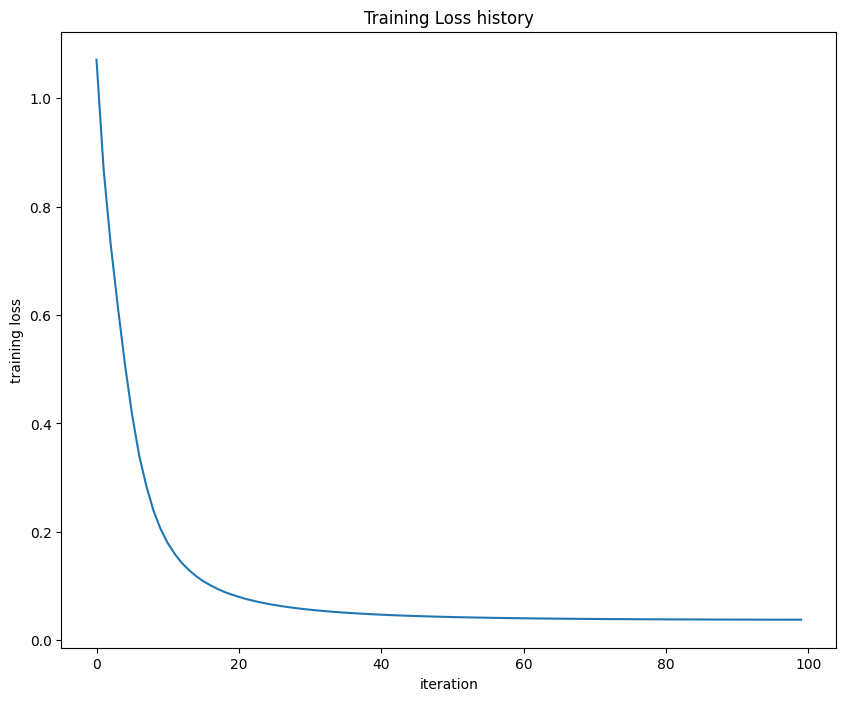

In [ ]:
net = init_toy_model(input_size, hidden_size, num_classes, std)
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

final_train_loss = stats['loss_history'][-1]
print('Final training loss: ', final_train_loss)
assert final_train_loss < 0.2, (
    f'Task 4.4 failed: final training loss too high ({final_train_loss:.6f} >= 0.2)'
)
print(f'Task 4.4 passed: final training loss is small ({final_train_loss:.6f}).')

# plot the loss history
plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()


# Load the data
Now that you have implemented a two-layer network that passes gradient checks and works on toy data, it's time to load up our favorite CIFAR-10 data so we can use it to train a classifier on a real dataset.

In [ ]:
from data_utils import load_CIFAR10

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):

    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the two-layer neural net classifier. These are the same steps as
    we used for the SVM, but condensed to a single function.  
    """

    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py/'
    X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar10_dir)
        
    # convert to Torch Tensors
    X_train_raw = torch.from_numpy(X_train_raw).float()
    y_train_raw = torch.from_numpy(y_train_raw).long()
    X_test_raw = torch.from_numpy(X_test_raw).float()
    y_test_raw = torch.from_numpy(y_test_raw).long()

    # Subsample the data
    mask_val = slice(num_training, num_training + num_validation)
    X_val = X_train_raw[mask_val]
    y_val = y_train_raw[mask_val]
    
    # Training
    mask_train = slice(0, num_training)
    X_train = X_train_raw[mask_train]
    y_train = y_train_raw[mask_train]
    
    # Test
    mask_test = slice(0, num_test)
    X_test = X_test_raw[mask_test]
    y_test = y_test_raw[mask_test]

    # Normalize the data: subtract the mean image
    mean_image = torch.mean(X_train, dim=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # Reshape data to rows
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test

# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

X_train = X_train.double()
X_val = X_val.double()
X_test = X_test.double()

print(f'Train data shape: {X_train.shape}')
print(f'Train labels shape: {y_train.shape}')
print(f'Validation data shape: {X_val.shape}')
print(f'Validation labels shape: {y_val.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')

d:\Artem\Tartu_CS\1st year\Neural Nets\HW4\data_utils.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Train data shape: torch.Size([49000, 3072])
Train labels shape: torch.Size([49000])
Validation data shape: torch.Size([1000, 3072])
Validation labels shape: torch.Size([1000])
Test data shape: torch.Size([1000, 3072])
Test labels shape: torch.Size([1000])


# Train a network
To train our network we will use SGD. In addition, we will adjust the learning rate with an exponential learning rate schedule as optimization proceeds; after each epoch, we will reduce the learning rate by multiplying it by a number smaller than one called "decay rate".

In [ ]:
input_size = 32 * 32 * 3  
hidden_size = 50
num_classes = 10
std = 1e-3

net = init_toy_model(input_size, hidden_size, num_classes, std)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

# Predict on the validation set
val_predictions = net.predict(X_val)
val_acc = torch.mean((val_predictions == y_val).float()).item()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.342349
iteration 100 / 1000: loss 2.300441
iteration 200 / 1000: loss 2.219120
iteration 300 / 1000: loss 2.165721
iteration 400 / 1000: loss 2.036960
iteration 500 / 1000: loss 2.011355
iteration 600 / 1000: loss 1.914130
iteration 700 / 1000: loss 2.019099
iteration 800 / 1000: loss 1.882130
iteration 900 / 1000: loss 1.962653
Validation accuracy:  0.35600000619888306


# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.29 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

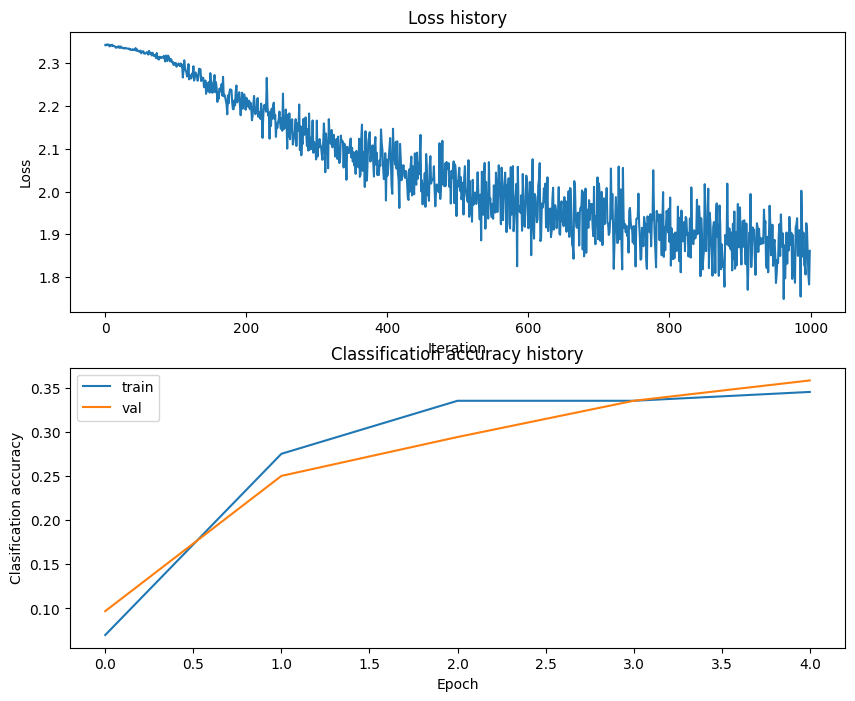

In [ ]:
# Plot the loss function and train / validation accuracies
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Clasification accuracy')
plt.legend()
plt.show()

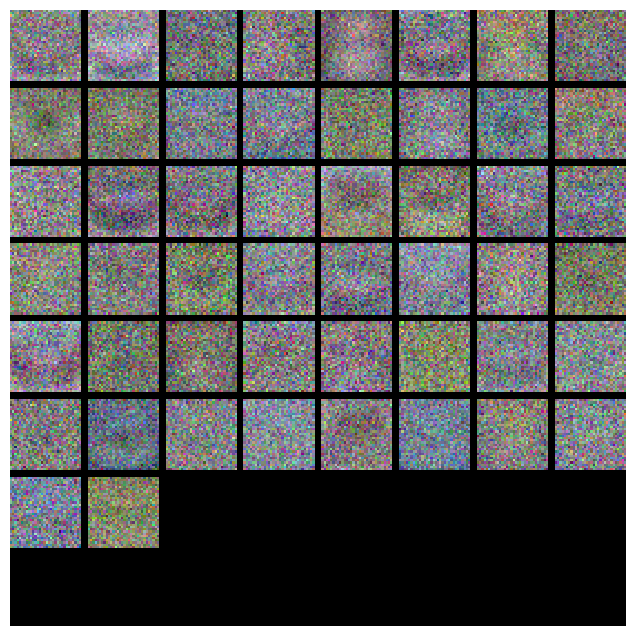

In [ ]:
from vis_utils import visualize_grid

def show_net_weights(net):

    W1 = net.params['W1'].detach().cpu().numpy()
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    
    grid = visualize_grid(W1, padding=3).astype('uint8')
    plt.imshow(grid)
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

### Task 4.5
**Experiment**: You goal in this exercise is to get as good of a result on CIFAR-10 as you can, with a fully-connected Neural Network. For every 1% above 52% on the Test set we will award you with one extra bonus point. Feel free implement your own techniques (e.g. PCA to reduce dimensionality, or adding dropout, or adding features to the solver, etc.).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss(stats, iterations_per_epoch=None, train_every=None):
    train_loss = np.asarray(stats.get('loss_history', []), dtype=float)
    val_loss = np.asarray(stats.get('val_loss_history', []), dtype=float)

    # Pick a reasonable default sampling interval for train-loss markers.
    if train_every is None:
        if iterations_per_epoch is not None:
            train_every = int(iterations_per_epoch)
        elif len(train_loss) > 0 and len(val_loss) > 1:
            train_every = max(1, int(round((len(train_loss) - 1) / (len(val_loss) - 1))))
        else:
            train_every = max(1, len(train_loss) // 20) if len(train_loss) > 0 else 1

    plt.figure(figsize=(8, 5))

    # Train loss: show a faint full curve + sparse markers every `train_every` iterations.
    if len(train_loss) > 0:
        it_train = np.arange(len(train_loss))
        plt.plot(it_train, train_loss, alpha=0.25, linewidth=1, label='train loss (all)')

        idx = np.arange(0, len(train_loss), train_every, dtype=int)
        plt.plot(it_train[idx], train_loss[idx], marker='o', linewidth=1, label=f'train loss (every {train_every})')

    # Validation loss: plotted at epoch boundaries on the same iteration axis.
    if len(val_loss) > 0:
        if iterations_per_epoch is None:
            # Validation loss is logged once per epoch (including at iter=0).
            # When we don't know iterations_per_epoch, infer x-positions so val points
            # span the same iteration axis as train_loss.
            if len(train_loss) > 0 and len(val_loss) > 1:
                x_val = np.linspace(0, len(train_loss) - 1, num=len(val_loss))
            else:
                x_val = np.arange(len(val_loss))
        else:
            x_val = np.arange(len(val_loss)) * iterations_per_epoch

        plt.plot(x_val, val_loss, label='val loss', marker='o', linewidth=1)

    plt.xlabel('iteration')
    plt.ylabel('loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
task45_model_cache = globals().get('task45_model_cache', {})
task45_sweep_history = globals().get('task45_sweep_history', [])
globals()['task45_model_cache'] = task45_model_cache
globals()['task45_sweep_history'] = task45_sweep_history

def task45_cache_key(lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay):
    return (lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay)

def task45_show_summary(results, title='Task 4.5 sweep summary'):
    ordered = sorted(results, key=lambda x: x['val_acc'], reverse=True)
    top = ordered[:min(12, len(ordered))]
    labels = [
        f"lr={r['params']['lr']:.0e}\nreg={r['params']['reg']:.2f}, h={r['params']['hidden_size']}, b={r['params']['batch_size']}"
        for r in top
    ]
    values = [r['val_acc'] for r in top]

    plt.figure(figsize=(10, max(4, 0.55 * len(top))))
    plt.barh(range(len(top)), values)
    plt.yticks(range(len(top)), labels)
    plt.gca().invert_yaxis()
    plt.xlabel('validation accuracy')
    plt.title(title)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    for idx, r in enumerate(ordered[:min(10, len(ordered))], start=1):
        p = r['params']
        print(
            f"{idx:02d}. val_acc={r['val_acc']:.4f} | "
            f"lr={p['lr']:.1e}, reg={p['reg']:.2f}, hidden={p['hidden_size']}, batch={p['batch_size']}"
        )

lr: 0.0003, reg: 0.05, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.302902
iteration 100 / 5000: loss 2.242344
iteration 200 / 5000: loss 2.070955
iteration 300 / 5000: loss 1.917775
iteration 400 / 5000: loss 1.856889
iteration 500 / 5000: loss 1.746125
iteration 600 / 5000: loss 1.706576
iteration 700 / 5000: loss 1.842338
iteration 800 / 5000: loss 1.804017
iteration 900 / 5000: loss 1.707160
iteration 1000 / 5000: loss 1.767493
iteration 1100 / 5000: loss 1.541006
iteration 1200 / 5000: loss 1.633749
iteration 1300 / 5000: loss 1.808594
iteration 1400 / 5000: loss 1.580100
iteration 1500 / 5000: loss 1.510619
iteration 1600 / 5000: loss 1.584496
iteration 1700 / 5000: loss 1.636566
iteration 1800 / 5000: loss 1.369304
iteration 1900 / 5000: loss 1.482035
iteration 2000 / 5000: loss 1.436924
iteration 2100 / 5000: loss 1.614232
iteration 2200 / 5000: loss 1.509174
iteration 2300 / 5000: loss 1.604548
iteration 2400 / 5000: loss 1.370460
iteration 2500 / 5000: loss 1.

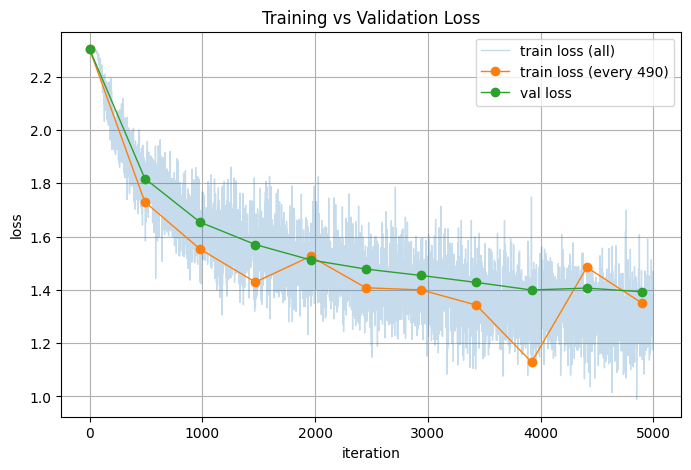

lr: 0.0003, reg: 0.05, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303197
iteration 100 / 5000: loss 2.208546
iteration 200 / 5000: loss 1.988764
iteration 300 / 5000: loss 1.847495
iteration 400 / 5000: loss 1.721477
iteration 500 / 5000: loss 1.696413
iteration 600 / 5000: loss 1.725464
iteration 700 / 5000: loss 1.694892
iteration 800 / 5000: loss 1.830063
iteration 900 / 5000: loss 1.743214
iteration 1000 / 5000: loss 1.465679
iteration 1100 / 5000: loss 1.664739
iteration 1200 / 5000: loss 1.538698
iteration 1300 / 5000: loss 1.623761
iteration 1400 / 5000: loss 1.451602
iteration 1500 / 5000: loss 1.594867
iteration 1600 / 5000: loss 1.614483
iteration 1700 / 5000: loss 1.542743
iteration 1800 / 5000: loss 1.560893
iteration 1900 / 5000: loss 1.345558
iteration 2000 / 5000: loss 1.758920
iteration 2100 / 5000: loss 1.455070
iteration 2200 / 5000: loss 1.532896
iteration 2300 / 5000: loss 1.421845
iteration 2400 / 5000: loss 1.398045
iteration 2500 / 5000: loss 1.

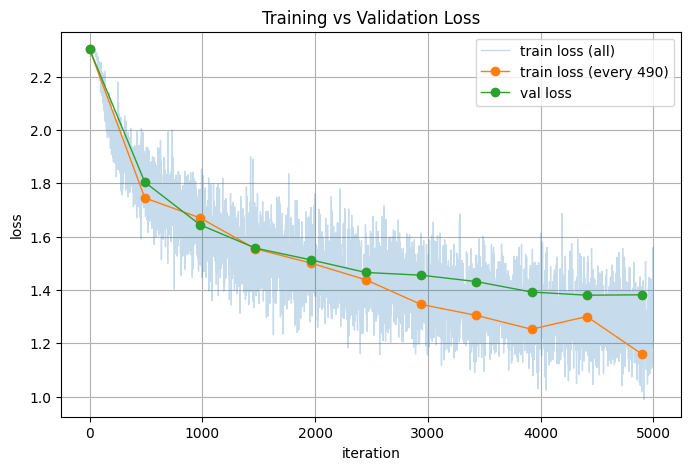

lr: 0.0003, reg: 0.1, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303167
iteration 100 / 5000: loss 2.224133
iteration 200 / 5000: loss 1.995167
iteration 300 / 5000: loss 1.870277
iteration 400 / 5000: loss 1.924274
iteration 500 / 5000: loss 1.737390
iteration 600 / 5000: loss 1.719588
iteration 700 / 5000: loss 1.656685
iteration 800 / 5000: loss 1.502340
iteration 900 / 5000: loss 1.643626
iteration 1000 / 5000: loss 1.661409
iteration 1100 / 5000: loss 1.579251
iteration 1200 / 5000: loss 1.500838
iteration 1300 / 5000: loss 1.570573
iteration 1400 / 5000: loss 1.701657
iteration 1500 / 5000: loss 1.597757
iteration 1600 / 5000: loss 1.563722
iteration 1700 / 5000: loss 1.648495
iteration 1800 / 5000: loss 1.502764
iteration 1900 / 5000: loss 1.625479
iteration 2000 / 5000: loss 1.397006
iteration 2100 / 5000: loss 1.419747
iteration 2200 / 5000: loss 1.535764
iteration 2300 / 5000: loss 1.398954
iteration 2400 / 5000: loss 1.532333
iteration 2500 / 5000: loss 1.3

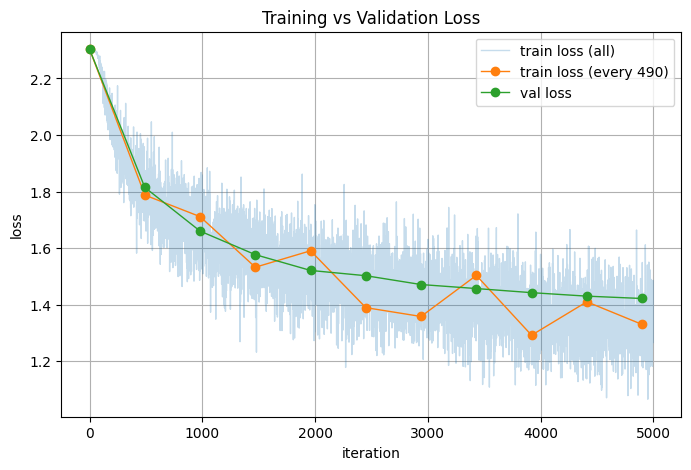

lr: 0.0003, reg: 0.1, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303744
iteration 100 / 5000: loss 2.261275
iteration 200 / 5000: loss 1.935522
iteration 300 / 5000: loss 1.853013
iteration 400 / 5000: loss 1.681995
iteration 500 / 5000: loss 1.935788
iteration 600 / 5000: loss 1.712606
iteration 700 / 5000: loss 1.800507
iteration 800 / 5000: loss 1.631869
iteration 900 / 5000: loss 1.469090
iteration 1000 / 5000: loss 1.644070
iteration 1100 / 5000: loss 1.698813
iteration 1200 / 5000: loss 1.599810
iteration 1300 / 5000: loss 1.629601
iteration 1400 / 5000: loss 1.452815
iteration 1500 / 5000: loss 1.486212
iteration 1600 / 5000: loss 1.613656
iteration 1700 / 5000: loss 1.498083
iteration 1800 / 5000: loss 1.511695
iteration 1900 / 5000: loss 1.583162
iteration 2000 / 5000: loss 1.560167
iteration 2100 / 5000: loss 1.597500
iteration 2200 / 5000: loss 1.521776
iteration 2300 / 5000: loss 1.494633
iteration 2400 / 5000: loss 1.619854
iteration 2500 / 5000: loss 1.3

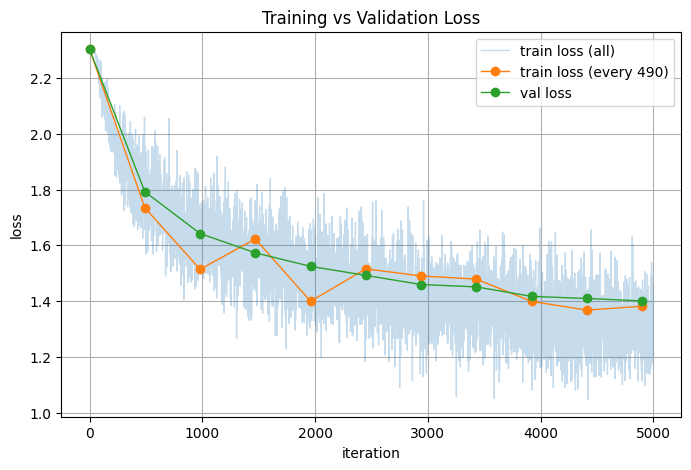

lr: 0.0003, reg: 0.15, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303492
iteration 100 / 5000: loss 2.214089
iteration 200 / 5000: loss 2.025215
iteration 300 / 5000: loss 2.007427
iteration 400 / 5000: loss 1.750076
iteration 500 / 5000: loss 1.793628
iteration 600 / 5000: loss 1.720131
iteration 700 / 5000: loss 1.592313
iteration 800 / 5000: loss 1.859175
iteration 900 / 5000: loss 1.602625
iteration 1000 / 5000: loss 1.686550
iteration 1100 / 5000: loss 1.722930
iteration 1200 / 5000: loss 1.642120
iteration 1300 / 5000: loss 1.576651
iteration 1400 / 5000: loss 1.504206
iteration 1500 / 5000: loss 1.311504
iteration 1600 / 5000: loss 1.439369
iteration 1700 / 5000: loss 1.446646
iteration 1800 / 5000: loss 1.446608
iteration 1900 / 5000: loss 1.500428
iteration 2000 / 5000: loss 1.512964
iteration 2100 / 5000: loss 1.412280
iteration 2200 / 5000: loss 1.600488
iteration 2300 / 5000: loss 1.509823
iteration 2400 / 5000: loss 1.381030
iteration 2500 / 5000: loss 1.

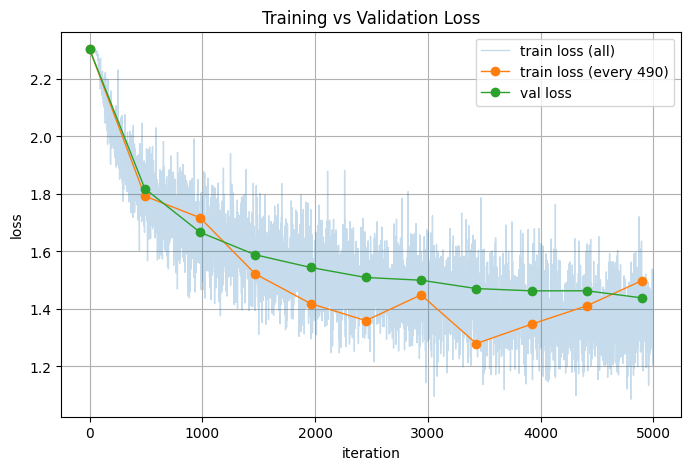

lr: 0.0003, reg: 0.15, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.304333
iteration 100 / 5000: loss 2.200380
iteration 200 / 5000: loss 1.945340
iteration 300 / 5000: loss 1.832551
iteration 400 / 5000: loss 1.867191
iteration 500 / 5000: loss 1.911791
iteration 600 / 5000: loss 1.775674
iteration 700 / 5000: loss 1.790635
iteration 800 / 5000: loss 1.645268
iteration 900 / 5000: loss 1.800400
iteration 1000 / 5000: loss 1.607872
iteration 1100 / 5000: loss 1.718770
iteration 1200 / 5000: loss 1.706064
iteration 1300 / 5000: loss 1.504401
iteration 1400 / 5000: loss 1.597080
iteration 1500 / 5000: loss 1.624446
iteration 1600 / 5000: loss 1.537776
iteration 1700 / 5000: loss 1.553383
iteration 1800 / 5000: loss 1.570309
iteration 1900 / 5000: loss 1.532144
iteration 2000 / 5000: loss 1.549835
iteration 2100 / 5000: loss 1.447784
iteration 2200 / 5000: loss 1.373701
iteration 2300 / 5000: loss 1.365102
iteration 2400 / 5000: loss 1.317975
iteration 2500 / 5000: loss 1.

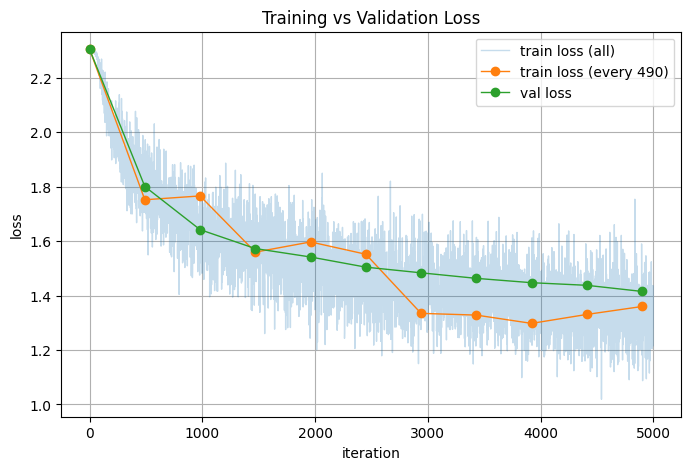

lr: 0.0003, reg: 0.2, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303780
iteration 100 / 5000: loss 2.219272
iteration 200 / 5000: loss 2.072706
iteration 300 / 5000: loss 1.929991
iteration 400 / 5000: loss 1.871357
iteration 500 / 5000: loss 1.768865
iteration 600 / 5000: loss 1.773043
iteration 700 / 5000: loss 1.739510
iteration 800 / 5000: loss 1.823266
iteration 900 / 5000: loss 1.830061
iteration 1000 / 5000: loss 1.665085
iteration 1100 / 5000: loss 1.484006
iteration 1200 / 5000: loss 1.576731
iteration 1300 / 5000: loss 1.710631
iteration 1400 / 5000: loss 1.596592
iteration 1500 / 5000: loss 1.722362
iteration 1600 / 5000: loss 1.411239
iteration 1700 / 5000: loss 1.746572
iteration 1800 / 5000: loss 1.490374
iteration 1900 / 5000: loss 1.539001
iteration 2000 / 5000: loss 1.513887
iteration 2100 / 5000: loss 1.652748
iteration 2200 / 5000: loss 1.529907
iteration 2300 / 5000: loss 1.523811
iteration 2400 / 5000: loss 1.355161
iteration 2500 / 5000: loss 1.5

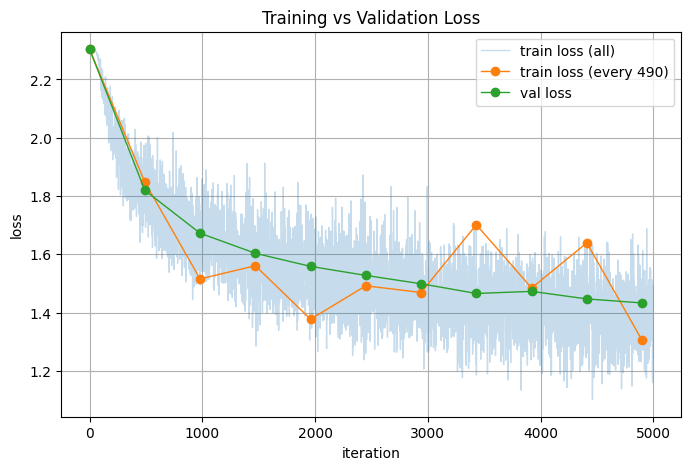

lr: 0.0003, reg: 0.2, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.305020
iteration 100 / 5000: loss 2.190909
iteration 200 / 5000: loss 2.026606
iteration 300 / 5000: loss 1.874025
iteration 400 / 5000: loss 1.953905
iteration 500 / 5000: loss 1.782864
iteration 600 / 5000: loss 1.812203
iteration 700 / 5000: loss 1.713947
iteration 800 / 5000: loss 1.805655
iteration 900 / 5000: loss 1.700250
iteration 1000 / 5000: loss 1.909004
iteration 1100 / 5000: loss 1.677485
iteration 1200 / 5000: loss 1.459092
iteration 1300 / 5000: loss 1.597100
iteration 1400 / 5000: loss 1.578974
iteration 1500 / 5000: loss 1.483318
iteration 1600 / 5000: loss 1.598377
iteration 1700 / 5000: loss 1.562386
iteration 1800 / 5000: loss 1.640110
iteration 1900 / 5000: loss 1.534314
iteration 2000 / 5000: loss 1.588010
iteration 2100 / 5000: loss 1.512538
iteration 2200 / 5000: loss 1.406496
iteration 2300 / 5000: loss 1.391790
iteration 2400 / 5000: loss 1.353933
iteration 2500 / 5000: loss 1.5

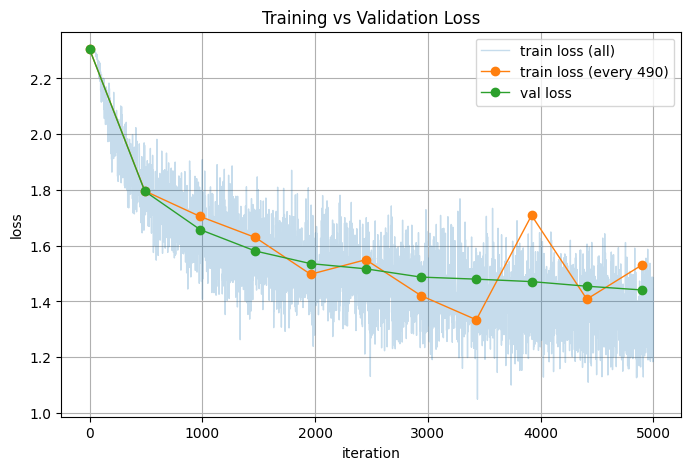

lr: 0.0005, reg: 0.05, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.302941
iteration 100 / 5000: loss 2.076156
iteration 200 / 5000: loss 1.872728
iteration 300 / 5000: loss 1.911576
iteration 400 / 5000: loss 1.630551
iteration 500 / 5000: loss 1.621917
iteration 600 / 5000: loss 1.628465
iteration 700 / 5000: loss 1.582840
iteration 800 / 5000: loss 1.714240
iteration 900 / 5000: loss 1.357666
iteration 1000 / 5000: loss 1.619906
iteration 1100 / 5000: loss 1.524234
iteration 1200 / 5000: loss 1.399963
iteration 1300 / 5000: loss 1.311384
iteration 1400 / 5000: loss 1.361260
iteration 1500 / 5000: loss 1.427533
iteration 1600 / 5000: loss 1.446083
iteration 1700 / 5000: loss 1.426118
iteration 1800 / 5000: loss 1.549362
iteration 1900 / 5000: loss 1.472532
iteration 2000 / 5000: loss 1.396707
iteration 2100 / 5000: loss 1.573873
iteration 2200 / 5000: loss 1.294394
iteration 2300 / 5000: loss 1.320125
iteration 2400 / 5000: loss 1.385971
iteration 2500 / 5000: loss 1.

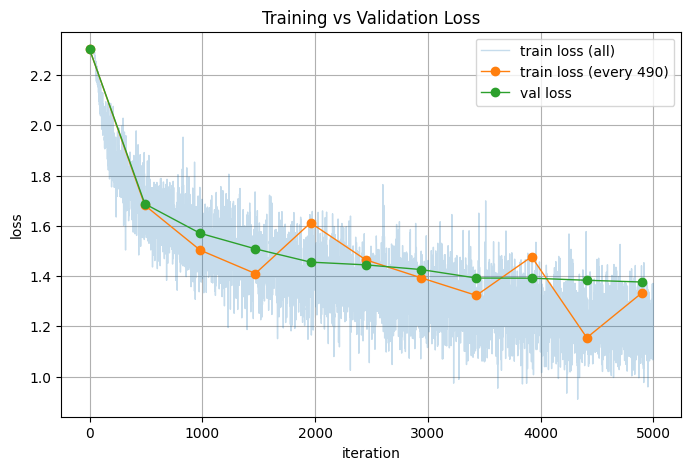

lr: 0.0005, reg: 0.05, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303168
iteration 100 / 5000: loss 2.088132
iteration 200 / 5000: loss 1.803793
iteration 300 / 5000: loss 1.825378
iteration 400 / 5000: loss 1.918315
iteration 500 / 5000: loss 1.663751
iteration 600 / 5000: loss 1.643964
iteration 700 / 5000: loss 1.520160
iteration 800 / 5000: loss 1.565943
iteration 900 / 5000: loss 1.574638
iteration 1000 / 5000: loss 1.552382
iteration 1100 / 5000: loss 1.567485
iteration 1200 / 5000: loss 1.456322
iteration 1300 / 5000: loss 1.486367
iteration 1400 / 5000: loss 1.484188
iteration 1500 / 5000: loss 1.442445
iteration 1600 / 5000: loss 1.354048
iteration 1700 / 5000: loss 1.349699
iteration 1800 / 5000: loss 1.436670
iteration 1900 / 5000: loss 1.582084
iteration 2000 / 5000: loss 1.344959
iteration 2100 / 5000: loss 1.328837
iteration 2200 / 5000: loss 1.341690
iteration 2300 / 5000: loss 1.234532
iteration 2400 / 5000: loss 1.326274
iteration 2500 / 5000: loss 1.

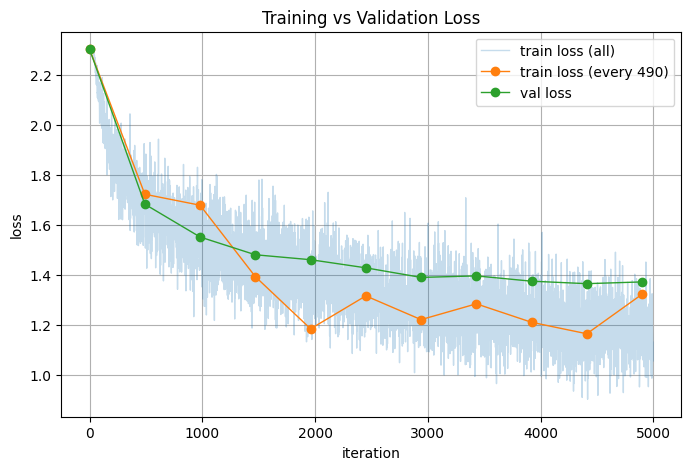

lr: 0.0005, reg: 0.1, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303121
iteration 100 / 5000: loss 2.078399
iteration 200 / 5000: loss 1.841214
iteration 300 / 5000: loss 1.887086
iteration 400 / 5000: loss 1.599650
iteration 500 / 5000: loss 1.663400
iteration 600 / 5000: loss 1.577097
iteration 700 / 5000: loss 1.564207
iteration 800 / 5000: loss 1.644665
iteration 900 / 5000: loss 1.510857
iteration 1000 / 5000: loss 1.520185
iteration 1100 / 5000: loss 1.543298
iteration 1200 / 5000: loss 1.437506
iteration 1300 / 5000: loss 1.524549
iteration 1400 / 5000: loss 1.575600
iteration 1500 / 5000: loss 1.492605
iteration 1600 / 5000: loss 1.512422
iteration 1700 / 5000: loss 1.538391
iteration 1800 / 5000: loss 1.499490
iteration 1900 / 5000: loss 1.353112
iteration 2000 / 5000: loss 1.464260
iteration 2100 / 5000: loss 1.316672
iteration 2200 / 5000: loss 1.158753
iteration 2300 / 5000: loss 1.403563
iteration 2400 / 5000: loss 1.380111
iteration 2500 / 5000: loss 1.5

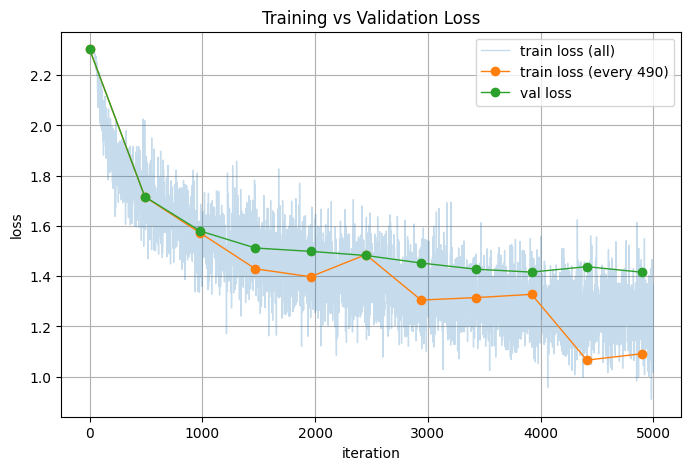

lr: 0.0005, reg: 0.1, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303841
iteration 100 / 5000: loss 2.012529
iteration 200 / 5000: loss 1.961192
iteration 300 / 5000: loss 1.798724
iteration 400 / 5000: loss 1.663534
iteration 500 / 5000: loss 1.842680
iteration 600 / 5000: loss 1.638651
iteration 700 / 5000: loss 1.521221
iteration 800 / 5000: loss 1.624825
iteration 900 / 5000: loss 1.420312
iteration 1000 / 5000: loss 1.475382
iteration 1100 / 5000: loss 1.551744
iteration 1200 / 5000: loss 1.481821
iteration 1300 / 5000: loss 1.477847
iteration 1400 / 5000: loss 1.518561
iteration 1500 / 5000: loss 1.725659
iteration 1600 / 5000: loss 1.457066
iteration 1700 / 5000: loss 1.528014
iteration 1800 / 5000: loss 1.371083
iteration 1900 / 5000: loss 1.574317
iteration 2000 / 5000: loss 1.343023
iteration 2100 / 5000: loss 1.552018
iteration 2200 / 5000: loss 1.415831
iteration 2300 / 5000: loss 1.431547
iteration 2400 / 5000: loss 1.300621
iteration 2500 / 5000: loss 1.3

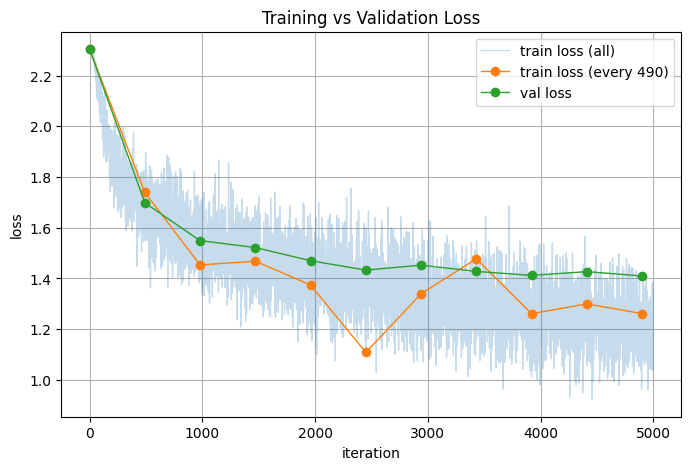

lr: 0.0005, reg: 0.15, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303473
iteration 100 / 5000: loss 2.056048
iteration 200 / 5000: loss 1.865240
iteration 300 / 5000: loss 1.696133
iteration 400 / 5000: loss 1.752579
iteration 500 / 5000: loss 1.591761
iteration 600 / 5000: loss 1.594825
iteration 700 / 5000: loss 1.620666
iteration 800 / 5000: loss 1.561434
iteration 900 / 5000: loss 1.582144
iteration 1000 / 5000: loss 1.695422
iteration 1100 / 5000: loss 1.573627
iteration 1200 / 5000: loss 1.438058
iteration 1300 / 5000: loss 1.486039
iteration 1400 / 5000: loss 1.739843
iteration 1500 / 5000: loss 1.505101
iteration 1600 / 5000: loss 1.392721
iteration 1700 / 5000: loss 1.338044
iteration 1800 / 5000: loss 1.552218
iteration 1900 / 5000: loss 1.366849
iteration 2000 / 5000: loss 1.580810
iteration 2100 / 5000: loss 1.476329
iteration 2200 / 5000: loss 1.388147
iteration 2300 / 5000: loss 1.385652
iteration 2400 / 5000: loss 1.432356
iteration 2500 / 5000: loss 1.

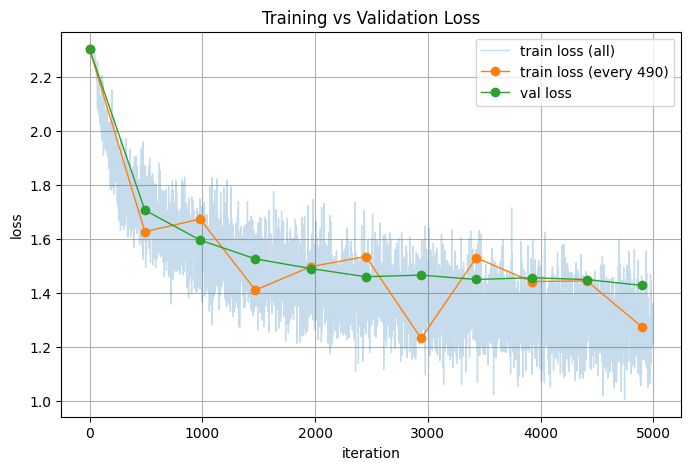

lr: 0.0005, reg: 0.15, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.304433
iteration 100 / 5000: loss 2.091498
iteration 200 / 5000: loss 1.906480
iteration 300 / 5000: loss 1.749469
iteration 400 / 5000: loss 1.609703
iteration 500 / 5000: loss 1.738341
iteration 600 / 5000: loss 1.791169
iteration 700 / 5000: loss 1.503903
iteration 800 / 5000: loss 1.603026
iteration 900 / 5000: loss 1.619533
iteration 1000 / 5000: loss 1.427257
iteration 1100 / 5000: loss 1.589384
iteration 1200 / 5000: loss 1.549970
iteration 1300 / 5000: loss 1.574468
iteration 1400 / 5000: loss 1.445726
iteration 1500 / 5000: loss 1.497017
iteration 1600 / 5000: loss 1.387111
iteration 1700 / 5000: loss 1.459353
iteration 1800 / 5000: loss 1.374434
iteration 1900 / 5000: loss 1.403694
iteration 2000 / 5000: loss 1.559782
iteration 2100 / 5000: loss 1.421870
iteration 2200 / 5000: loss 1.334629
iteration 2300 / 5000: loss 1.437311
iteration 2400 / 5000: loss 1.254002
iteration 2500 / 5000: loss 1.

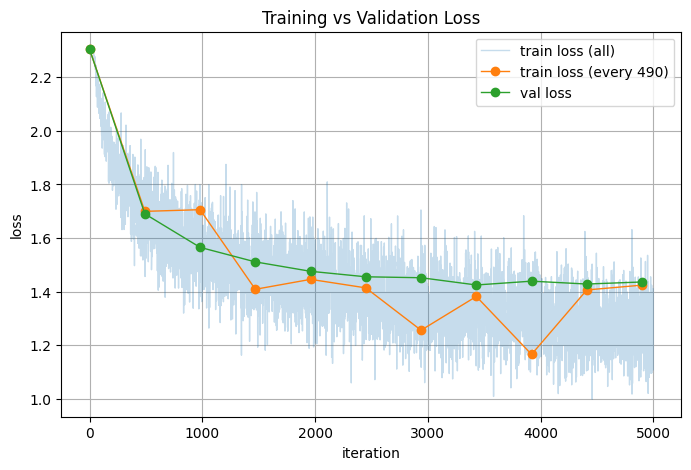

lr: 0.0005, reg: 0.2, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303788
iteration 100 / 5000: loss 2.053160
iteration 200 / 5000: loss 1.996897
iteration 300 / 5000: loss 1.683263
iteration 400 / 5000: loss 1.670272
iteration 500 / 5000: loss 1.604061
iteration 600 / 5000: loss 1.719043
iteration 700 / 5000: loss 1.845580
iteration 800 / 5000: loss 1.535478
iteration 900 / 5000: loss 1.585197
iteration 1000 / 5000: loss 1.567572
iteration 1100 / 5000: loss 1.513514
iteration 1200 / 5000: loss 1.471901
iteration 1300 / 5000: loss 1.499563
iteration 1400 / 5000: loss 1.564662
iteration 1500 / 5000: loss 1.398966
iteration 1600 / 5000: loss 1.444295
iteration 1700 / 5000: loss 1.357614
iteration 1800 / 5000: loss 1.548384
iteration 1900 / 5000: loss 1.607044
iteration 2000 / 5000: loss 1.478262
iteration 2100 / 5000: loss 1.596884
iteration 2200 / 5000: loss 1.559992
iteration 2300 / 5000: loss 1.561087
iteration 2400 / 5000: loss 1.443393
iteration 2500 / 5000: loss 1.1

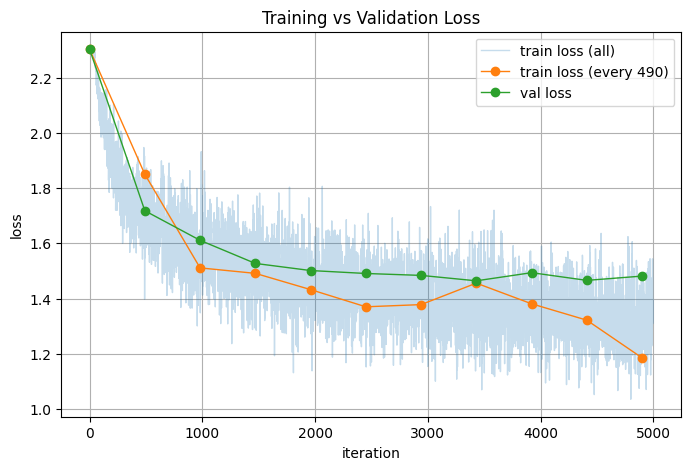

lr: 0.0005, reg: 0.2, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.305093
iteration 100 / 5000: loss 2.084274
iteration 200 / 5000: loss 1.866521
iteration 300 / 5000: loss 1.740367
iteration 400 / 5000: loss 1.693100
iteration 500 / 5000: loss 1.789309
iteration 600 / 5000: loss 1.558593
iteration 700 / 5000: loss 1.620207
iteration 800 / 5000: loss 1.616417
iteration 900 / 5000: loss 1.555095
iteration 1000 / 5000: loss 1.663269
iteration 1100 / 5000: loss 1.442898
iteration 1200 / 5000: loss 1.459503
iteration 1300 / 5000: loss 1.476194
iteration 1400 / 5000: loss 1.578605
iteration 1500 / 5000: loss 1.434952
iteration 1600 / 5000: loss 1.449717
iteration 1700 / 5000: loss 1.481917
iteration 1800 / 5000: loss 1.313280
iteration 1900 / 5000: loss 1.446164
iteration 2000 / 5000: loss 1.352218
iteration 2100 / 5000: loss 1.529703
iteration 2200 / 5000: loss 1.524843
iteration 2300 / 5000: loss 1.336780
iteration 2400 / 5000: loss 1.395660
iteration 2500 / 5000: loss 1.4

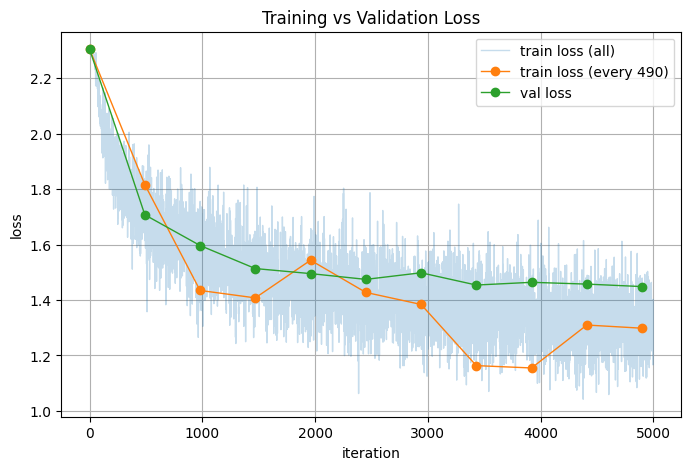

lr: 0.0007, reg: 0.05, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.302934
iteration 100 / 5000: loss 1.893775
iteration 200 / 5000: loss 1.867515
iteration 300 / 5000: loss 1.695152
iteration 400 / 5000: loss 1.634769
iteration 500 / 5000: loss 1.592404
iteration 600 / 5000: loss 1.551965
iteration 700 / 5000: loss 1.585284
iteration 800 / 5000: loss 1.506171
iteration 900 / 5000: loss 1.602657
iteration 1000 / 5000: loss 1.704338
iteration 1100 / 5000: loss 1.562311
iteration 1200 / 5000: loss 1.316899
iteration 1300 / 5000: loss 1.440775
iteration 1400 / 5000: loss 1.511174
iteration 1500 / 5000: loss 1.369524
iteration 1600 / 5000: loss 1.285694
iteration 1700 / 5000: loss 1.258032
iteration 1800 / 5000: loss 1.315125
iteration 1900 / 5000: loss 1.402873
iteration 2000 / 5000: loss 1.435232
iteration 2100 / 5000: loss 1.385564
iteration 2200 / 5000: loss 1.436400
iteration 2300 / 5000: loss 1.349321
iteration 2400 / 5000: loss 1.262450
iteration 2500 / 5000: loss 1.

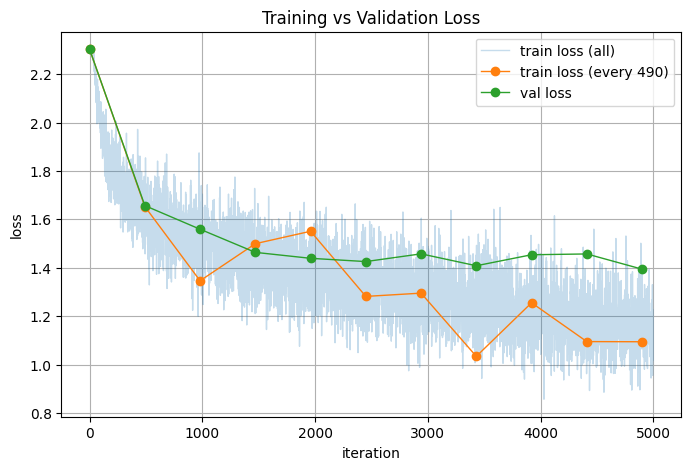

lr: 0.0007, reg: 0.05, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303195
iteration 100 / 5000: loss 1.912987
iteration 200 / 5000: loss 1.809160
iteration 300 / 5000: loss 1.779691
iteration 400 / 5000: loss 1.724746
iteration 500 / 5000: loss 1.604182
iteration 600 / 5000: loss 1.484898
iteration 700 / 5000: loss 1.403193
iteration 800 / 5000: loss 1.555144
iteration 900 / 5000: loss 1.590109
iteration 1000 / 5000: loss 1.439506
iteration 1100 / 5000: loss 1.430687
iteration 1200 / 5000: loss 1.446043
iteration 1300 / 5000: loss 1.408266
iteration 1400 / 5000: loss 1.533849
iteration 1500 / 5000: loss 1.350370
iteration 1600 / 5000: loss 1.448343
iteration 1700 / 5000: loss 1.403383
iteration 1800 / 5000: loss 1.297478
iteration 1900 / 5000: loss 1.523540
iteration 2000 / 5000: loss 1.377733
iteration 2100 / 5000: loss 1.483122
iteration 2200 / 5000: loss 1.315462
iteration 2300 / 5000: loss 1.269550
iteration 2400 / 5000: loss 1.303441
iteration 2500 / 5000: loss 1.

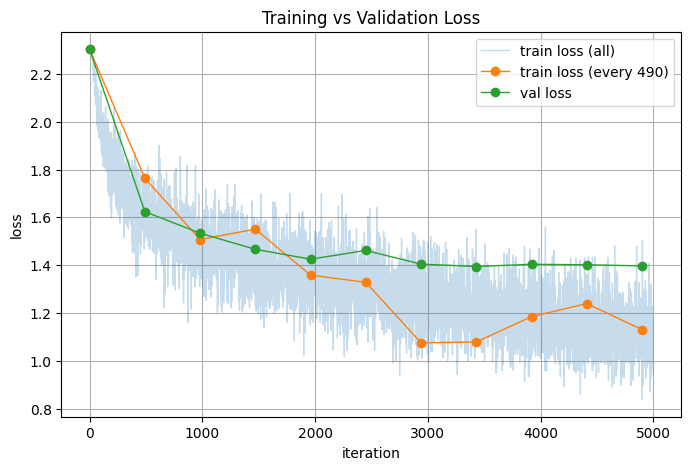

lr: 0.0007, reg: 0.1, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303224
iteration 100 / 5000: loss 1.958371
iteration 200 / 5000: loss 1.720486
iteration 300 / 5000: loss 1.698851
iteration 400 / 5000: loss 1.851110
iteration 500 / 5000: loss 1.604876
iteration 600 / 5000: loss 1.426906
iteration 700 / 5000: loss 1.424843
iteration 800 / 5000: loss 1.474272
iteration 900 / 5000: loss 1.516950
iteration 1000 / 5000: loss 1.615595
iteration 1100 / 5000: loss 1.575944
iteration 1200 / 5000: loss 1.528246
iteration 1300 / 5000: loss 1.440691
iteration 1400 / 5000: loss 1.411600
iteration 1500 / 5000: loss 1.648923
iteration 1600 / 5000: loss 1.368959
iteration 1700 / 5000: loss 1.419938
iteration 1800 / 5000: loss 1.462035
iteration 1900 / 5000: loss 1.431703
iteration 2000 / 5000: loss 1.353896
iteration 2100 / 5000: loss 1.442035
iteration 2200 / 5000: loss 1.277359
iteration 2300 / 5000: loss 1.356990
iteration 2400 / 5000: loss 1.250318
iteration 2500 / 5000: loss 1.4

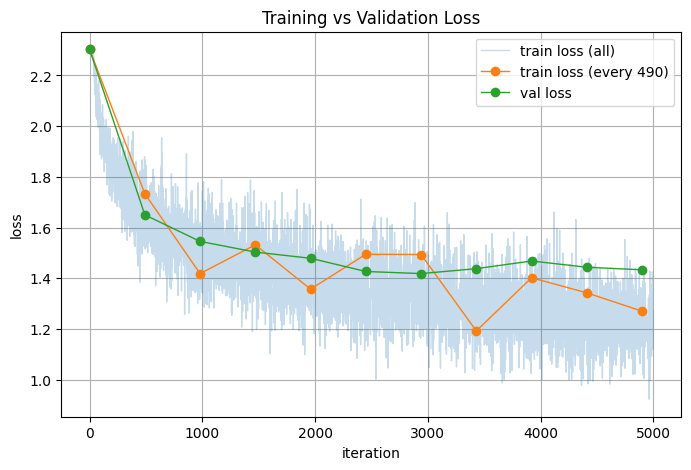

lr: 0.0007, reg: 0.1, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303794
iteration 100 / 5000: loss 2.034162
iteration 200 / 5000: loss 1.925857
iteration 300 / 5000: loss 1.778612
iteration 400 / 5000: loss 1.592498
iteration 500 / 5000: loss 1.675174
iteration 600 / 5000: loss 1.597590
iteration 700 / 5000: loss 1.714303
iteration 800 / 5000: loss 1.616102
iteration 900 / 5000: loss 1.491936
iteration 1000 / 5000: loss 1.366456
iteration 1100 / 5000: loss 1.489863
iteration 1200 / 5000: loss 1.377435
iteration 1300 / 5000: loss 1.314575
iteration 1400 / 5000: loss 1.618700
iteration 1500 / 5000: loss 1.539389
iteration 1600 / 5000: loss 1.430743
iteration 1700 / 5000: loss 1.415033
iteration 1800 / 5000: loss 1.377422
iteration 1900 / 5000: loss 1.463657
iteration 2000 / 5000: loss 1.349054
iteration 2100 / 5000: loss 1.476131
iteration 2200 / 5000: loss 1.657813
iteration 2300 / 5000: loss 1.264264
iteration 2400 / 5000: loss 1.649138
iteration 2500 / 5000: loss 1.2

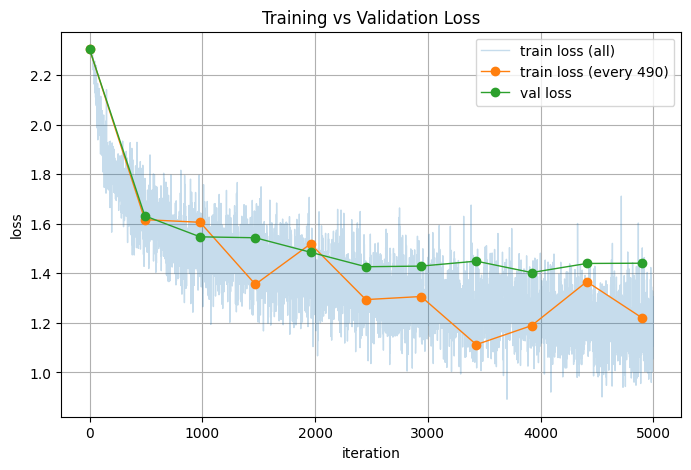

lr: 0.0007, reg: 0.15, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303493
iteration 100 / 5000: loss 1.970687
iteration 200 / 5000: loss 1.886293
iteration 300 / 5000: loss 1.829790
iteration 400 / 5000: loss 1.742559
iteration 500 / 5000: loss 1.559902
iteration 600 / 5000: loss 1.633531
iteration 700 / 5000: loss 1.855758
iteration 800 / 5000: loss 1.553543
iteration 900 / 5000: loss 1.493956
iteration 1000 / 5000: loss 1.634783
iteration 1100 / 5000: loss 1.358333
iteration 1200 / 5000: loss 1.592299
iteration 1300 / 5000: loss 1.637230
iteration 1400 / 5000: loss 1.410908
iteration 1500 / 5000: loss 1.487595
iteration 1600 / 5000: loss 1.331764
iteration 1700 / 5000: loss 1.368605
iteration 1800 / 5000: loss 1.444526
iteration 1900 / 5000: loss 1.620068
iteration 2000 / 5000: loss 1.511814
iteration 2100 / 5000: loss 1.323835
iteration 2200 / 5000: loss 1.466421
iteration 2300 / 5000: loss 1.450936
iteration 2400 / 5000: loss 1.271535
iteration 2500 / 5000: loss 1.

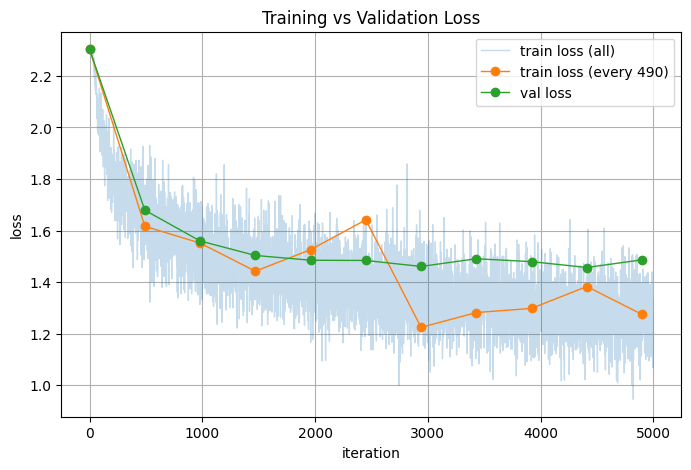

lr: 0.0007, reg: 0.15, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.304525
iteration 100 / 5000: loss 1.973865
iteration 200 / 5000: loss 1.880953
iteration 300 / 5000: loss 1.662041
iteration 400 / 5000: loss 1.766034
iteration 500 / 5000: loss 1.575180
iteration 600 / 5000: loss 1.378447
iteration 700 / 5000: loss 1.590659
iteration 800 / 5000: loss 1.415850
iteration 900 / 5000: loss 1.567970
iteration 1000 / 5000: loss 1.559921
iteration 1100 / 5000: loss 1.564284
iteration 1200 / 5000: loss 1.379150
iteration 1300 / 5000: loss 1.375558
iteration 1400 / 5000: loss 1.433376
iteration 1500 / 5000: loss 1.355001
iteration 1600 / 5000: loss 1.453216
iteration 1700 / 5000: loss 1.453765
iteration 1800 / 5000: loss 1.355041
iteration 1900 / 5000: loss 1.321865
iteration 2000 / 5000: loss 1.327278
iteration 2100 / 5000: loss 1.308528
iteration 2200 / 5000: loss 1.577044
iteration 2300 / 5000: loss 1.379213
iteration 2400 / 5000: loss 1.433218
iteration 2500 / 5000: loss 1.

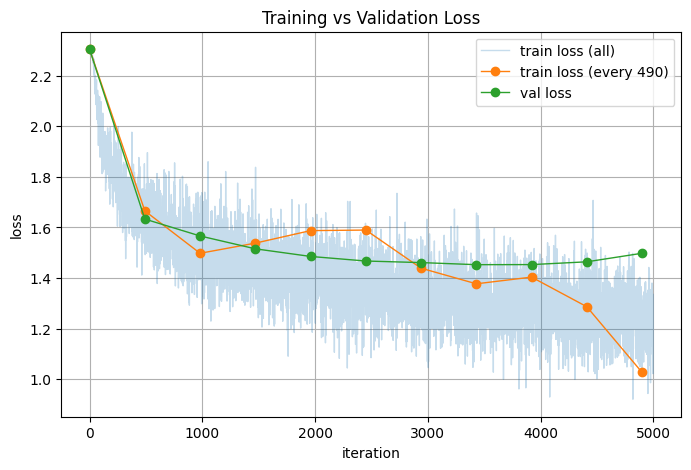

lr: 0.0007, reg: 0.2, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303765
iteration 100 / 5000: loss 1.973093
iteration 200 / 5000: loss 1.825506
iteration 300 / 5000: loss 1.699367
iteration 400 / 5000: loss 1.721409
iteration 500 / 5000: loss 1.515380
iteration 600 / 5000: loss 1.498768
iteration 700 / 5000: loss 1.502596
iteration 800 / 5000: loss 1.577871
iteration 900 / 5000: loss 1.680274
iteration 1000 / 5000: loss 1.463110
iteration 1100 / 5000: loss 1.429435
iteration 1200 / 5000: loss 1.492211
iteration 1300 / 5000: loss 1.567433
iteration 1400 / 5000: loss 1.511471
iteration 1500 / 5000: loss 1.533036
iteration 1600 / 5000: loss 1.426315
iteration 1700 / 5000: loss 1.442949
iteration 1800 / 5000: loss 1.450438
iteration 1900 / 5000: loss 1.418659
iteration 2000 / 5000: loss 1.620431
iteration 2100 / 5000: loss 1.566005
iteration 2200 / 5000: loss 1.637984
iteration 2300 / 5000: loss 1.494609
iteration 2400 / 5000: loss 1.501480
iteration 2500 / 5000: loss 1.2

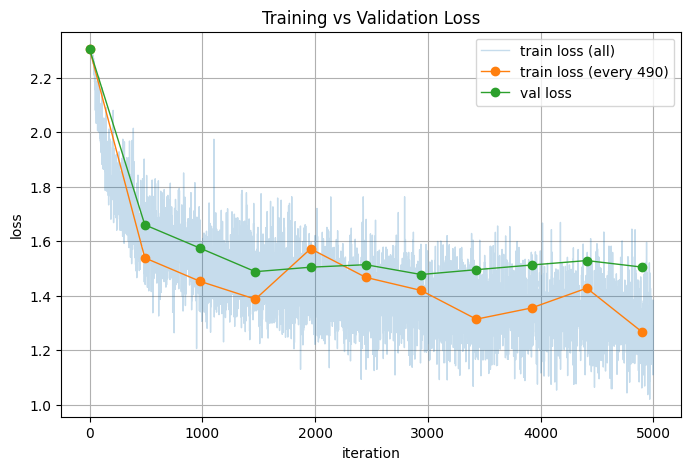

lr: 0.0007, reg: 0.2, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.304971
iteration 100 / 5000: loss 1.990382
iteration 200 / 5000: loss 1.809795
iteration 300 / 5000: loss 1.788369
iteration 400 / 5000: loss 1.794761
iteration 500 / 5000: loss 1.789800
iteration 600 / 5000: loss 1.552459
iteration 700 / 5000: loss 1.621132
iteration 800 / 5000: loss 1.373125
iteration 900 / 5000: loss 1.563500
iteration 1000 / 5000: loss 1.500633
iteration 1100 / 5000: loss 1.442200
iteration 1200 / 5000: loss 1.384896
iteration 1300 / 5000: loss 1.450794
iteration 1400 / 5000: loss 1.531799
iteration 1500 / 5000: loss 1.465212
iteration 1600 / 5000: loss 1.457321
iteration 1700 / 5000: loss 1.375251
iteration 1800 / 5000: loss 1.511121
iteration 1900 / 5000: loss 1.486775
iteration 2000 / 5000: loss 1.309677
iteration 2100 / 5000: loss 1.636333
iteration 2200 / 5000: loss 1.449444
iteration 2300 / 5000: loss 1.320434
iteration 2400 / 5000: loss 1.504494
iteration 2500 / 5000: loss 1.4

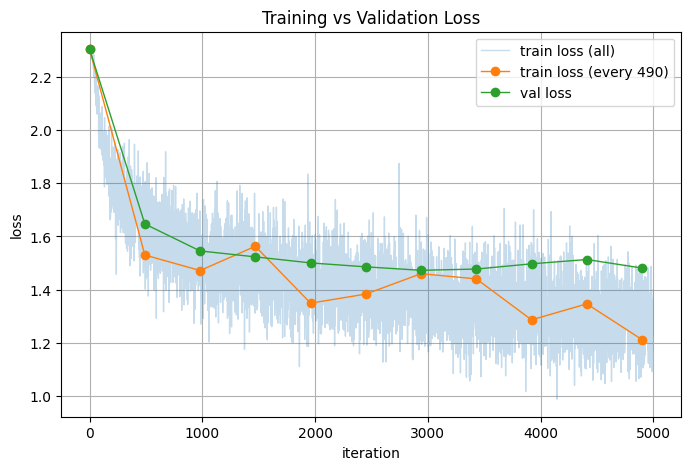

lr: 0.001, reg: 0.05, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.302896
iteration 100 / 5000: loss 1.861028
iteration 200 / 5000: loss 1.773833
iteration 300 / 5000: loss 1.658482
iteration 400 / 5000: loss 1.624256
iteration 500 / 5000: loss 1.570142
iteration 600 / 5000: loss 1.761674
iteration 700 / 5000: loss 1.544046
iteration 800 / 5000: loss 1.596695
iteration 900 / 5000: loss 1.762097
iteration 1000 / 5000: loss 1.444990
iteration 1100 / 5000: loss 1.533921
iteration 1200 / 5000: loss 1.544767
iteration 1300 / 5000: loss 1.386320
iteration 1400 / 5000: loss 1.229111
iteration 1500 / 5000: loss 1.533455
iteration 1600 / 5000: loss 1.332544
iteration 1700 / 5000: loss 1.358290
iteration 1800 / 5000: loss 1.553650
iteration 1900 / 5000: loss 1.282698
iteration 2000 / 5000: loss 1.526856
iteration 2100 / 5000: loss 1.085374
iteration 2200 / 5000: loss 1.208344
iteration 2300 / 5000: loss 1.262150
iteration 2400 / 5000: loss 1.485425
iteration 2500 / 5000: loss 1.2

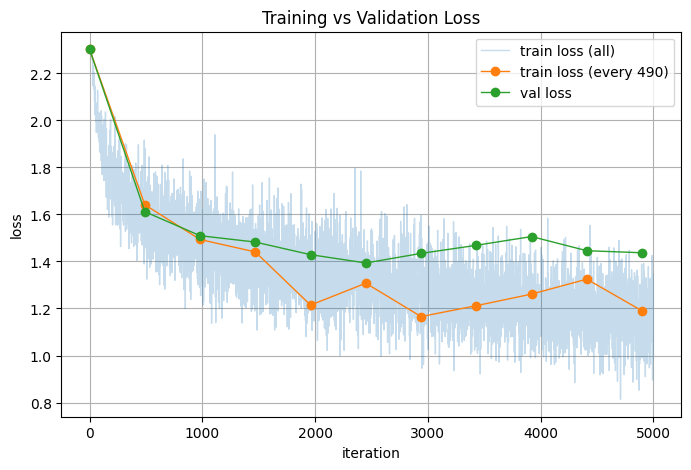

lr: 0.001, reg: 0.05, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303108
iteration 100 / 5000: loss 1.922040
iteration 200 / 5000: loss 1.831011
iteration 300 / 5000: loss 1.735801
iteration 400 / 5000: loss 1.369120
iteration 500 / 5000: loss 1.471134
iteration 600 / 5000: loss 1.618460
iteration 700 / 5000: loss 1.470066
iteration 800 / 5000: loss 1.381126
iteration 900 / 5000: loss 1.345274
iteration 1000 / 5000: loss 1.652417
iteration 1100 / 5000: loss 1.391889
iteration 1200 / 5000: loss 1.279448
iteration 1300 / 5000: loss 1.434371
iteration 1400 / 5000: loss 1.358122
iteration 1500 / 5000: loss 1.469614
iteration 1600 / 5000: loss 1.522397
iteration 1700 / 5000: loss 1.294362
iteration 1800 / 5000: loss 1.322997
iteration 1900 / 5000: loss 1.232421
iteration 2000 / 5000: loss 1.300802
iteration 2100 / 5000: loss 1.185161
iteration 2200 / 5000: loss 1.382963
iteration 2300 / 5000: loss 1.447021
iteration 2400 / 5000: loss 1.485768
iteration 2500 / 5000: loss 1.2

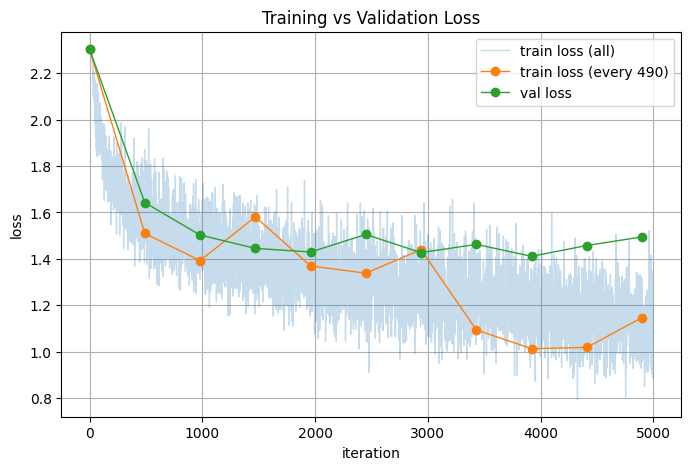

lr: 0.001, reg: 0.1, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303272
iteration 100 / 5000: loss 1.891667
iteration 200 / 5000: loss 1.615011
iteration 300 / 5000: loss 1.680965
iteration 400 / 5000: loss 1.643792
iteration 500 / 5000: loss 1.523088
iteration 600 / 5000: loss 1.628722
iteration 700 / 5000: loss 1.754338
iteration 800 / 5000: loss 1.593936
iteration 900 / 5000: loss 1.556322
iteration 1000 / 5000: loss 1.452379
iteration 1100 / 5000: loss 1.407100
iteration 1200 / 5000: loss 1.686605
iteration 1300 / 5000: loss 1.551291
iteration 1400 / 5000: loss 1.507632
iteration 1500 / 5000: loss 1.385563
iteration 1600 / 5000: loss 1.515248
iteration 1700 / 5000: loss 1.374355
iteration 1800 / 5000: loss 1.316021
iteration 1900 / 5000: loss 1.388410
iteration 2000 / 5000: loss 1.317339
iteration 2100 / 5000: loss 1.471683
iteration 2200 / 5000: loss 1.422890
iteration 2300 / 5000: loss 1.309701
iteration 2400 / 5000: loss 1.286624
iteration 2500 / 5000: loss 1.05

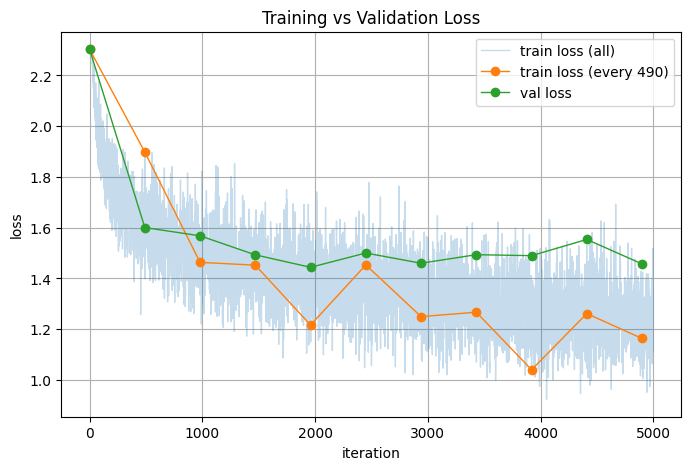

lr: 0.001, reg: 0.1, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.303783
iteration 100 / 5000: loss 1.809462
iteration 200 / 5000: loss 1.903477
iteration 300 / 5000: loss 1.700292
iteration 400 / 5000: loss 1.581894
iteration 500 / 5000: loss 1.418180
iteration 600 / 5000: loss 1.582284
iteration 700 / 5000: loss 1.368165
iteration 800 / 5000: loss 1.672783
iteration 900 / 5000: loss 1.503048
iteration 1000 / 5000: loss 1.345595
iteration 1100 / 5000: loss 1.383279
iteration 1200 / 5000: loss 1.500391
iteration 1300 / 5000: loss 1.664385
iteration 1400 / 5000: loss 1.348378
iteration 1500 / 5000: loss 1.413627
iteration 1600 / 5000: loss 1.580876
iteration 1700 / 5000: loss 1.441145
iteration 1800 / 5000: loss 1.284893
iteration 1900 / 5000: loss 1.355707
iteration 2000 / 5000: loss 1.377383
iteration 2100 / 5000: loss 1.269509
iteration 2200 / 5000: loss 1.529983
iteration 2300 / 5000: loss 1.204732
iteration 2400 / 5000: loss 1.324395
iteration 2500 / 5000: loss 1.37

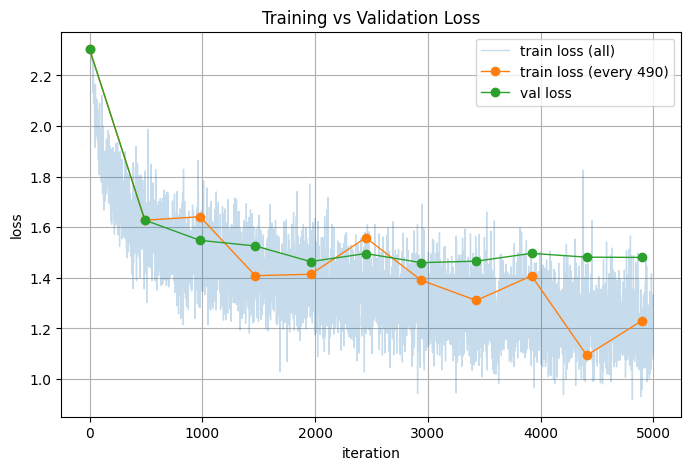

lr: 0.001, reg: 0.15, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303469
iteration 100 / 5000: loss 1.791006
iteration 200 / 5000: loss 1.939345
iteration 300 / 5000: loss 1.828469
iteration 400 / 5000: loss 1.608162
iteration 500 / 5000: loss 1.526376
iteration 600 / 5000: loss 1.445253
iteration 700 / 5000: loss 1.574461
iteration 800 / 5000: loss 1.736275
iteration 900 / 5000: loss 1.592576
iteration 1000 / 5000: loss 1.782467
iteration 1100 / 5000: loss 1.395038
iteration 1200 / 5000: loss 1.432988
iteration 1300 / 5000: loss 1.498729
iteration 1400 / 5000: loss 1.481750
iteration 1500 / 5000: loss 1.460340
iteration 1600 / 5000: loss 1.515750
iteration 1700 / 5000: loss 1.233391
iteration 1800 / 5000: loss 1.400745
iteration 1900 / 5000: loss 1.376249
iteration 2000 / 5000: loss 1.368137
iteration 2100 / 5000: loss 1.316757
iteration 2200 / 5000: loss 1.114611
iteration 2300 / 5000: loss 1.318066
iteration 2400 / 5000: loss 1.270108
iteration 2500 / 5000: loss 1.4

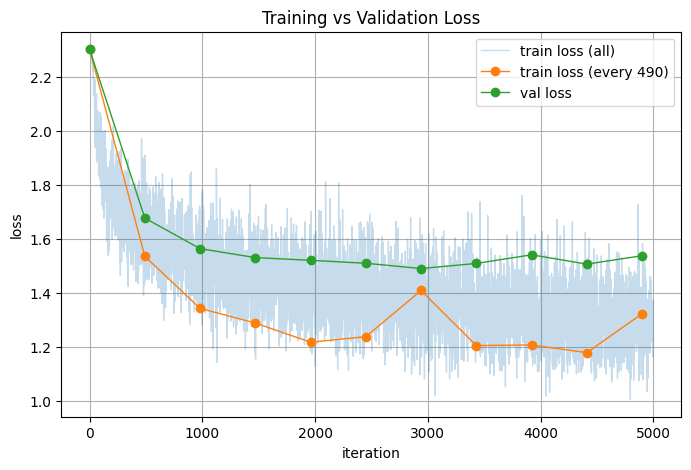

lr: 0.001, reg: 0.15, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.304483
iteration 100 / 5000: loss 1.734082
iteration 200 / 5000: loss 1.777791
iteration 300 / 5000: loss 1.678281
iteration 400 / 5000: loss 1.584407
iteration 500 / 5000: loss 1.671657
iteration 600 / 5000: loss 1.528519
iteration 700 / 5000: loss 1.539087
iteration 800 / 5000: loss 1.457532
iteration 900 / 5000: loss 1.499223
iteration 1000 / 5000: loss 1.582378
iteration 1100 / 5000: loss 1.666776
iteration 1200 / 5000: loss 1.360321
iteration 1300 / 5000: loss 1.366350
iteration 1400 / 5000: loss 1.424330
iteration 1500 / 5000: loss 1.573623
iteration 1600 / 5000: loss 1.367272
iteration 1700 / 5000: loss 1.191746
iteration 1800 / 5000: loss 1.517113
iteration 1900 / 5000: loss 1.462649
iteration 2000 / 5000: loss 1.543560
iteration 2100 / 5000: loss 1.195527
iteration 2200 / 5000: loss 1.489919
iteration 2300 / 5000: loss 1.497860
iteration 2400 / 5000: loss 1.314209
iteration 2500 / 5000: loss 1.3

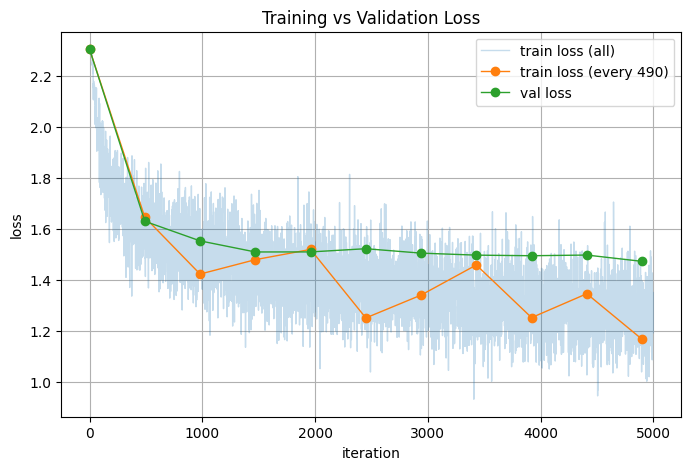

lr: 0.001, reg: 0.2, hidden_size: 200, batch_size: 100
iteration 0 / 5000: loss 2.303843
iteration 100 / 5000: loss 1.942213
iteration 200 / 5000: loss 1.719722
iteration 300 / 5000: loss 1.811606
iteration 400 / 5000: loss 1.405414
iteration 500 / 5000: loss 1.489879
iteration 600 / 5000: loss 1.720814
iteration 700 / 5000: loss 1.385325
iteration 800 / 5000: loss 1.594009
iteration 900 / 5000: loss 1.652101
iteration 1000 / 5000: loss 1.619893
iteration 1100 / 5000: loss 1.453526
iteration 1200 / 5000: loss 1.516814
iteration 1300 / 5000: loss 1.491733
iteration 1400 / 5000: loss 1.423953
iteration 1500 / 5000: loss 1.370761
iteration 1600 / 5000: loss 1.648710
iteration 1700 / 5000: loss 1.463233
iteration 1800 / 5000: loss 1.429638
iteration 1900 / 5000: loss 1.350366
iteration 2000 / 5000: loss 1.366630
iteration 2100 / 5000: loss 1.433626
iteration 2200 / 5000: loss 1.507701
iteration 2300 / 5000: loss 1.323308
iteration 2400 / 5000: loss 1.579248
iteration 2500 / 5000: loss 1.20

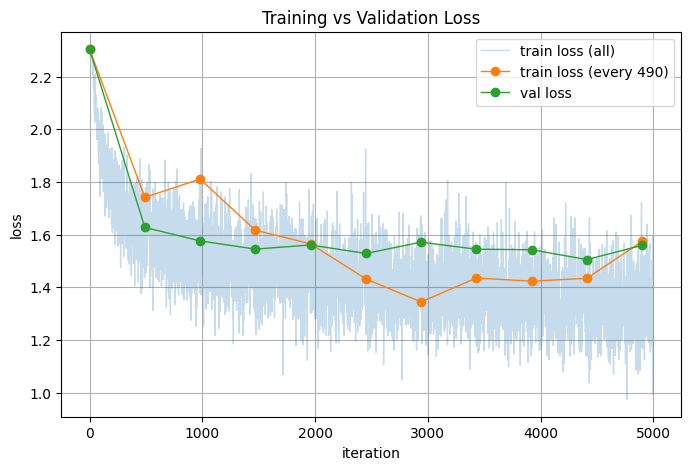

lr: 0.001, reg: 0.2, hidden_size: 400, batch_size: 100
iteration 0 / 5000: loss 2.305082
iteration 100 / 5000: loss 2.023556
iteration 200 / 5000: loss 1.642303
iteration 300 / 5000: loss 1.624903
iteration 400 / 5000: loss 1.630080
iteration 500 / 5000: loss 1.573025
iteration 600 / 5000: loss 1.639002
iteration 700 / 5000: loss 1.498881
iteration 800 / 5000: loss 1.444956
iteration 900 / 5000: loss 1.680557
iteration 1000 / 5000: loss 1.573737
iteration 1100 / 5000: loss 1.563713
iteration 1200 / 5000: loss 1.402183
iteration 1300 / 5000: loss 1.568796
iteration 1400 / 5000: loss 1.569643
iteration 1500 / 5000: loss 1.503599
iteration 1600 / 5000: loss 1.348303
iteration 1700 / 5000: loss 1.410106
iteration 1800 / 5000: loss 1.602562
iteration 1900 / 5000: loss 1.491938
iteration 2000 / 5000: loss 1.346967
iteration 2100 / 5000: loss 1.277174
iteration 2200 / 5000: loss 1.739612
iteration 2300 / 5000: loss 1.518094
iteration 2400 / 5000: loss 1.350175
iteration 2500 / 5000: loss 1.54

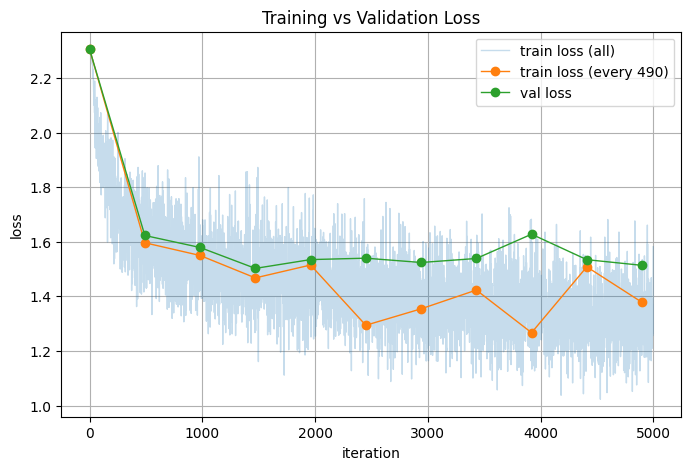

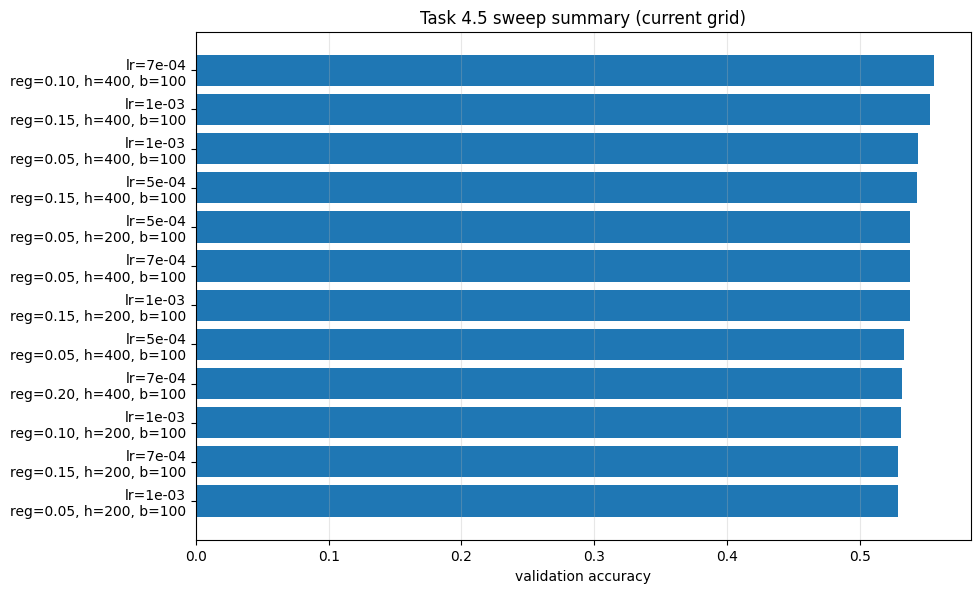

01. val_acc=0.5560 | lr=7.0e-04, reg=0.10, hidden=400, batch=100
02. val_acc=0.5530 | lr=1.0e-03, reg=0.15, hidden=400, batch=100
03. val_acc=0.5440 | lr=1.0e-03, reg=0.05, hidden=400, batch=100
04. val_acc=0.5430 | lr=5.0e-04, reg=0.15, hidden=400, batch=100
05. val_acc=0.5380 | lr=5.0e-04, reg=0.05, hidden=200, batch=100
06. val_acc=0.5380 | lr=7.0e-04, reg=0.05, hidden=400, batch=100
07. val_acc=0.5380 | lr=1.0e-03, reg=0.15, hidden=200, batch=100
08. val_acc=0.5330 | lr=5.0e-04, reg=0.05, hidden=400, batch=100
09. val_acc=0.5320 | lr=7.0e-04, reg=0.20, hidden=400, batch=100
10. val_acc=0.5310 | lr=1.0e-03, reg=0.10, hidden=200, batch=100
Task 4.5 setup passed: hyperparameter lists are non-empty and include a sweep dimension.
Task 4.5 passed: best model selected with validation accuracy 0.5560.


In [ ]:
best_net = None # store the best model into this 

#################################################################################
# Task 4.5                                                                      #
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_net.                                                            #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on the previous exercises.                          #
#################################################################################

input_size = 32 * 32 * 3
num_classes = 10
std = 1e-4
num_iters = 7000
learning_rate_decay = 0.95

learning_rates = [3e-4, 5e-4, 7e-4, 1e-3]
regularization_strengths = [0.05, 0.1, 0.15, 0.2]
hidden_sizes = [200, 400]
batch_sizes = [100]

best_val = -1
current_results = []

for lr in learning_rates:
    for reg in regularization_strengths:
        for hidden_size in hidden_sizes:
            for batch_size in batch_sizes:

                # Initialize a new network for each set of hyperparameters
                print(f"lr: {lr}, reg: {reg}, hidden_size: {hidden_size}, batch_size: {batch_size}")

                key = task45_cache_key(lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay)

                if key in task45_model_cache:
                    result = task45_model_cache[key]
                    net = result['net']
                    stats = result['stats']
                    val_acc = result['val_acc']
                else:
                    net = init_toy_model(input_size, hidden_size, num_classes, std)

                    stats = net.train(X_train, y_train, X_val, y_val,
                                num_iters=num_iters, batch_size=batch_size,
                                learning_rate=lr, learning_rate_decay=learning_rate_decay,
                                reg=reg, verbose=True)

                    # Predict on the validation set
                    val_predictions = net.predict(X_val)
                    val_acc = torch.mean((val_predictions == y_val).float()).item()
                    result = {
                        'key': key,
                        'params': {
                            'lr': lr,
                            'reg': reg,
                            'hidden_size': hidden_size,
                            'batch_size': batch_size,
                            'std': std,
                            'num_iters': num_iters,
                            'learning_rate_decay': learning_rate_decay,
                        },
                        'net': net,
                        'stats': stats,
                        'val_acc': val_acc,
                    }
                    task45_model_cache[key] = result
                    task45_sweep_history.append(result)

                print('Validation accuracy: ', val_acc)
                print(f'lr: {lr:.1e}, reg: {reg:.2f}, hidden: {hidden_size}, batch: {batch_size}, val_acc: {val_acc:.4f}')
                plot_train_val_loss(stats, iterations_per_epoch=max(X_train.shape[0] // batch_size, 1))
                current_results.append(result)

                if val_acc > best_val:
                    best_val = val_acc
                    best_net = net

#################################################################################
#                               END OF YOUR CODE                                #
#################################################################################

globals()['best_net'] = best_net
globals()['task45_best_result'] = max(current_results, key=lambda x: x['val_acc'])
task45_show_summary(current_results, title='Task 4.5 sweep summary (current grid)')

hyperparam_lists = [learning_rates, regularization_strengths, hidden_sizes, batch_sizes]
assert all(len(lst) > 0 for lst in hyperparam_lists), (
    'Task 4.5 failed: all hyperparameter lists must be non-empty.'
)
assert any(len(lst) > 1 for lst in hyperparam_lists), (
    'Task 4.5 failed: at least one hyperparameter list must contain more than one value.'
)
print('Task 4.5 setup passed: hyperparameter lists are non-empty and include a sweep dimension.')
assert best_net is not None, 'Task 4.5 failed: best_net was not set.'
print(f'Task 4.5 passed: best model selected with validation accuracy {best_val:.4f}.')

### Task 4.6
Describe how different hyperparameters seem to affect the result and what might be their interactions. Which are the most important and which are less important? Be thorough and mention all hyperparameters you tried. Describe what you see, not general case from textbook.

**Your answer:** 

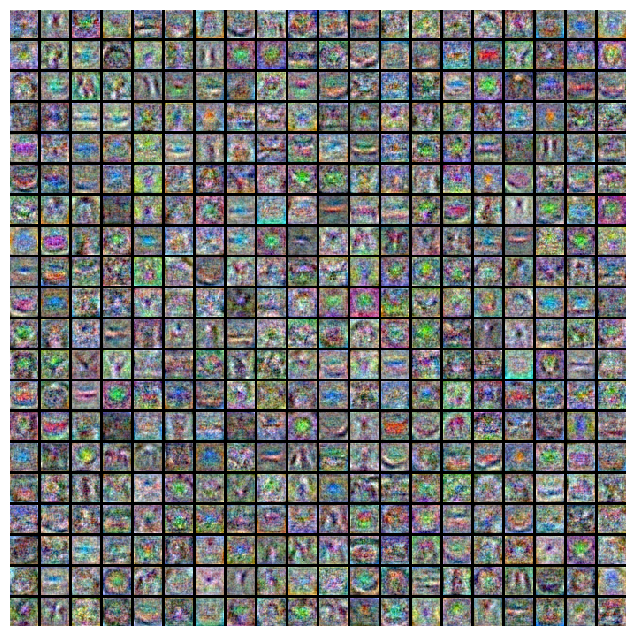

In [ ]:
# visualize the weights of the best network
show_net_weights(best_net)

# Run on the test set
When you are done experimenting, you should evaluate your final trained network on the test set; you should get above 48%.

### Bonus Task (up to 5 pts):
**We will give you extra bonus point for every 1% of accuracy above 52%. (up to a maximum 5 bonus points)**

In [ ]:
test_acc = (best_net.predict(X_test) == y_test).to(torch.float64).mean().item()
print('Test accuracy: ', test_acc)
assert test_acc > 0.48, f'Test-set requirement failed: accuracy too low ({test_acc:.4f} <= 0.48)'
print(f'Test-set check passed: accuracy is above 48% ({test_acc:.4f}).')

above_52_pct_points = max(0.0, (test_acc - 0.52) * 100.0)
bonus_points = min(5.0, above_52_pct_points)
print(f'Above 52% by: {above_52_pct_points:.2f} percentage points.')
print(f'Bonus points (capped at 5): {bonus_points:.2f}')


Test accuracy:  0.536
Test-set check passed: accuracy is above 48% (0.5360).
Above 52% by: 1.60 percentage points.
Bonus points (capped at 5): 1.60


In [ ]:
# test set across the top-6 models
task45_sweep_history = globals().get('task45_sweep_history', [])
top_models = sorted(task45_sweep_history, key=lambda x: x['val_acc'], reverse=True)[:10]
print('Test accuracy for top-10 models (by validation accuracy):\n')
for i, result in enumerate(top_models, 1):
    net = result['net']
    p = result['params']
    test_acc = (net.predict(X_test) == y_test).to(torch.float64).mean().item()
    print(f"  {i}. val_acc={result['val_acc']:.4f}  test_acc={test_acc:.4f}  "
            f"lr={p['lr']:.1e}, reg={p['reg']:.2f}, hidden={p['hidden_size']}, batch={p['batch_size']}, "
            f"bonus points: {round(max(0.0, (test_acc - 0.52) * 100.0),2)}")

Test accuracy for top-6 models (by validation accuracy):

  1. val_acc=0.5560  test_acc=0.5360  lr=7.0e-04, reg=0.10, hidden=400, batch=100, bonus points: 1.6
  2. val_acc=0.5530  test_acc=0.5200  lr=1.0e-03, reg=0.15, hidden=400, batch=100, bonus points: 0.0
  3. val_acc=0.5440  test_acc=0.5370  lr=1.0e-03, reg=0.05, hidden=400, batch=100, bonus points: 1.7
  4. val_acc=0.5430  test_acc=0.5490  lr=5.0e-04, reg=0.15, hidden=400, batch=100, bonus points: 2.9
  5. val_acc=0.5380  test_acc=0.5350  lr=5.0e-04, reg=0.05, hidden=200, batch=100, bonus points: 1.5
  6. val_acc=0.5380  test_acc=0.5310  lr=7.0e-04, reg=0.05, hidden=400, batch=100, bonus points: 1.1
